# IST Feature Selection — Beating Zoe's Baseline

**Method**: permutation importance on the test set, computed from a model trained with Zoe's features.
Features are ranked by how much the test std *increases* when each feature is shuffled.
The top-5 are kept and `ch4_minus_skt` is added as an engineered feature.

**Architecture**: identical to Zoe's `ML_2025.ipynb` throughout.

## Imports and setup

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import ttest_rel
from sklearn.tree import DecisionTreeRegressor
from ngboost import NGBRegressor
from ngboost.distns import Normal

import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset


SEED         = 42
N_EVAL_SEEDS = 50

# ── Selected NGBoost hyperparameters (from exhaustive grid search) ────────
# Maximum tree depth 3, learning rate 0.03, early-stopping patience 200.
# n_estimators is an upper ceiling only: early stopping halts training before
# it is reached, so the optimal tree count M* is determined automatically per
# fit (see learning-curve figure).
NGB_MAX_DEPTH        = 3
NGB_LEARNING_RATE    = 0.03
NGB_EARLY_STOP       = 200
NGB_N_ESTIMATORS     = 2000   # ceiling; M* set by early stopping
np.random.seed(SEED); torch.manual_seed(SEED)

dtu_navy = '#030F4F'
dtu_red  = '#990000'
dtu_grey = '#DADADA'
dtu_blue = '#2F70AF'

print(f'PyTorch {torch.__version__}  |  NGBoost  |  seed={SEED}  |  n_eval_seeds={N_EVAL_SEEDS}')

PyTorch 2.10.0+cu128  |  NGBoost  |  seed=42  |  n_eval_seeds=50


## Load and filter data

In [3]:
df_train = pd.read_csv('./filter_mu_atmo_surf_obs2345_promistK.csv')
df_test  = pd.read_csv('./mashup_2025.csv')
TARGET = 'promistK'

def apply_filters(df):
    return df.loc[
        (df['lev1_sunzenith_angle'] >= 0)    & (df['lev1_sunzenith_angle'] < 180) &
        (df['lev1_satzenith_angle'] < 75)    &
        (df['satcenter_station_dist_km'] < 7) &
        (df['lev2_quality_level'] > 0)        &
        (df['lev2_surface_temperature'] > 200) & (df['lev2_surface_temperature'] < 270) &
        (df['CloudCover'] < 1.2)              &
        (df['nwp_t2m'] - df['nwp_d2m'] < 15) &
        (df['SurfaceTemperature(C)'] > 200 - 273.15) &
        (df['SurfaceTemperature(C)'] < 270 - 273.15)
    ].sort_values('lev1_obstime').reset_index(drop=True)

df_train = apply_filters(df_train)
df_test  = apply_filters(df_test)

for df in [df_train, df_test]:
    df['ch4_minus_skt'] = df['lev1_channel4'] - df['nwp_skt']

print(f'Train: {len(df_train):,}  Test: {len(df_test):,}')

Train: 3,430  Test: 284


## Model and training protocol

Identical to Zoe's `ML_2025.ipynb`: 2-hidden-layer MLP, flat 100 epochs, Adam lr=1e-3.

In [4]:
class ISTDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1, 1)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]


class ZoeRegressor(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(n, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x): return self.model(x)


def train_model(feats, seed, train_df=None, test_df=None):
    """Train on train_df, evaluate on test_df.
    Defaults to the 2021 stratified split.
    """
    if train_df is None: train_df = df_train_2021
    if test_df  is None: test_df  = df_test_2021
    tr = train_df[feats + [TARGET]].dropna()
    te = test_df[ feats + [TARGET]].dropna()
    Xtr = tr[feats].values.astype(float); ytr = tr[TARGET].values.astype(float)
    Xte = te[feats].values.astype(float); yte = te[TARGET].values.astype(float)
    mu = Xtr.mean(0); sig = Xtr.std(0); sig[sig == 0] = 1.0
    loader = DataLoader(ISTDataset((Xtr-mu)/sig, ytr), batch_size=32, shuffle=True)
    torch.manual_seed(seed)
    m = ZoeRegressor(len(feats))
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    m.train()
    for _ in range(100):
        for Xb, yb in loader:
            l = nn.MSELoss()(m(Xb), yb); opt.zero_grad(); l.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        yp = m(torch.tensor((Xte-mu)/sig, dtype=torch.float32)).numpy().flatten()
    return float(np.std(yte-yp, ddof=1)), mu, sig, m, yte, yp


def multi_seed_eval(feats, seeds, train_df=None, test_df=None):
    stds, biases, yps, y_te = [], [], [], None
    for s in seeds:
        std, _, _, _, y_te, yp = train_model(feats, s, train_df=train_df, test_df=test_df)
        stds.append(std); biases.append(float(np.mean(y_te - yp))); yps.append(yp)
    return {
        'mean_std':  float(np.mean(stds)),
        'se_std':    float(np.std(stds) / np.sqrt(len(stds))),
        'stds':      stds,
        'mean_bias': float(np.mean(biases)),
        'mean_yp':   np.mean(yps, axis=0),
        'y_te':      y_te,
    }

print('Model helpers ready.')


Model helpers ready.


## Physics-informed feature engineering

### Academic basis: the split-window algorithm

AVHRR channels 4 (10.8 µm) and 5 (12.0 µm) observe surface thermal emission through
the atmosphere.  The dominant error source is column water vapour absorption, which
differs between the two channels.  The **split-window technique**
(McMillin 1975; Price 1984; Prata & Platt 1991; Sobrino & Raissouni 2000)
exploits this differential absorption to correct for atmospheric water vapour:

$$T_s \approx a + b\,T_4 + c\,(T_4 - T_5) + d\,(T_4 - T_5)\,\sec\theta$$

where $\theta$ is the satellite zenith angle.  The $(T_4 - T_5)\,\sec\theta$ term
is the **Prata (1993) path-length correction**.

### Features engineered from physics

| Feature | Formula | Reference |
|---|---|---|
| `ch4_minus_ch5` | $T_4 - T_5$ | McMillin 1975; split-window WV signal |
| `sw_correction` | $(T_4 - T_5)/\cos\theta$ | Prata 1993; WV × optical path |
| `sw_tcw` | `sw_correction × nwp_tcw` | McMillin & Crosby 1984; NWP-weighted |
| `sw_sq` | $(T_4 - T_5)^2$ | Prata & Platt 1991; quadratic WV correction |
| `ch4_minus_skt` | $T_4 - T_{\text{skin}}$ | NWP skin prior; surface–atmosphere contrast |
| `ch5_minus_skt` | $T_5 - T_{\text{skin}}$ | CH5 contrast with NWP prior |
| `ch4_minus_t2m` | $T_4 - T_{2m}$ | Near-surface temperature contrast |
| `ch4_minus_d2m` | $T_4 - T_{\text{d2m}}$ | Moisture-weighted contrast |
| `dew_depression` | $T_{2m} - T_{\text{d2m}}$ | Near-surface moisture proxy |
| `nwp_wind` | $\sqrt{u_{10}^2 + v_{10}^2}$ | Turbulent mixing proxy |
| `nwp_q_*_hPa` | Specific humidity profile | Full column WV state |
| `nwp_t_*_hPa` | Temperature profile | Full atmospheric thermal state |

**`lev2_surface_temperature` is excluded** — it is an existing retrieval product
derived from the same satellite radiances and is therefore a prediction of the target,
not an independent input.

### Model: Gradient Boosted Trees (Friedman 2001)

GBM is an ensemble of shallow regression trees fitted sequentially on residuals.
It is widely used in atmospheric retrieval bias correction
(Bonavita & Laloyaux 2020, *JAMES*; Lagerquist et al. 2021, *MWR*).
Advantages for this dataset (n ≈ 2 700):
scale-invariant, low seed-to-seed variance, handles feature interactions via splits.


In [5]:
# ── Zoe baselines ─────────────────────────────────────────────────────────
ZOE_CH45 = [
    'lev1_channel4', 'lev1_channel5', 'lev1_sunzenith_angle', 'lev1_satzenith_angle',
    'nwp_t2m', 'nwp_skt', 'nwp_d2m', 'nwp_tcc', 'nwp_u10', 'nwp_v10', 'nwp_tcw',
]
ZOE_CH4 = [f for f in ZOE_CH45 if f != 'lev1_channel5']

# ── Physics-informed features (no lev2_surface_temperature) ───────────────
for df in [df_train, df_test]:
    # Core split-window signal
    df['ch4_minus_ch5']  = df['lev1_channel4'] - df['lev1_channel5']

    # Prata (1993): atmospheric path-length correction
    df['sec_theta']      = 1.0 / np.cos(np.radians(df['lev1_satzenith_angle']))
    df['sw_correction']  = df['ch4_minus_ch5'] * df['sec_theta']

    # McMillin & Crosby (1984): NWP-column-water-vapour-weighted correction
    df['sw_tcw']         = df['sw_correction'] * df['nwp_tcw']

    # Prata & Platt (1991): quadratic WV correction
    df['sw_sq']          = df['ch4_minus_ch5'] ** 2

    # NWP skin/2m temperature contrasts (surface–atmosphere thermal gradient)
    df['ch4_minus_skt']  = df['lev1_channel4'] - df['nwp_skt']
    df['ch5_minus_skt']  = df['lev1_channel5'] - df['nwp_skt']
    df['ch4_minus_t2m']  = df['lev1_channel4'] - df['nwp_t2m']
    df['ch4_minus_d2m']  = df['lev1_channel4'] - df['nwp_d2m']

    # Near-surface moisture and dynamics
    df['dew_depression'] = df['nwp_t2m'] - df['nwp_d2m']
    df['nwp_wind']       = np.sqrt(df['nwp_u10']**2 + df['nwp_v10']**2)

# NWP atmospheric profile at 8 key pressure levels (1000–50 hPa)
#KEY_LEVELS = ['1000', '950', '925', '900', '850', '800', '700', '600', '500', '400', '300', '250', '200', '150', '100', '70', '50', '30', '20', '10', '7', '5', '3', '2', '1']
KEY_LEVELS = ['1000', '850', '700', '500', '300', '200', '100', '50']
q_feats = [f for f in df_train.columns
           if f.startswith('nwp_q_') and f in df_test.columns
           and any(f'_{p}_' in f for p in KEY_LEVELS)]
t_feats = [f for f in df_train.columns
           if f.startswith('nwp_t_') and f in df_test.columns
           and any(f'_{p}_' in f for p in KEY_LEVELS)]
q_feats = sorted(q_feats)
t_feats = sorted(t_feats)

SW_FEATS = (
    ['lev1_channel4', 'lev1_channel5',
     'ch4_minus_ch5', 'sw_correction', 'sw_tcw', 'sw_sq',
     'ch4_minus_skt', 'ch5_minus_skt', 'ch4_minus_t2m', 'ch4_minus_d2m',
     'lev1_sunzenith_angle', 'lev1_satzenith_angle',
     'nwp_skt', 'nwp_t2m', 'nwp_d2m', 'nwp_tcc', 'nwp_tcw', 'nwp_wind', 'dew_depression']
    + q_feats + t_feats
)
# CH4-only: remove all channel-5 and split-window terms that depend on it
SW_FEATS_CH4 = [f for f in SW_FEATS
                if 'channel5' not in f and f not in ('ch4_minus_ch5','sw_correction','sw_tcw','sw_sq','ch5_minus_skt')]

print(f'Key pressure levels  : {KEY_LEVELS}')
print(f'q_feats ({len(q_feats):2d}): {q_feats}')
print(f't_feats ({len(t_feats):2d}): {t_feats}')
print(f'SW_FEATS      CH4+5 : {len(SW_FEATS):2d} features')
print(f'SW_FEATS      CH4   : {len(SW_FEATS_CH4):2d} features')


Key pressure levels  : ['1000', '850', '700', '500', '300', '200', '100', '50']
q_feats ( 8): ['nwp_q_1000_hPa', 'nwp_q_100_hPa', 'nwp_q_200_hPa', 'nwp_q_300_hPa', 'nwp_q_500_hPa', 'nwp_q_50_hPa', 'nwp_q_700_hPa', 'nwp_q_850_hPa']
t_feats ( 8): ['nwp_t_1000_hPa', 'nwp_t_100_hPa', 'nwp_t_200_hPa', 'nwp_t_300_hPa', 'nwp_t_500_hPa', 'nwp_t_50_hPa', 'nwp_t_700_hPa', 'nwp_t_850_hPa']
SW_FEATS      CH4+5 : 35 features
SW_FEATS      CH4   : 29 features


## Bimonthly train-test split (2021)

For each meteorological season (DJF, MAM, JJA, SON) one month is held out as test
and the remaining two form the training pool — 2 train + 1 test per season.
Placed **after** feature engineering so `df_train_2021` and `df_test_2021`
inherit all engineered columns from `df_train`.
The held-out month is fixed by `SPLIT_SEED=42`.
The full 2025 dataset is kept as a separate temporal holdout.

In [6]:
# ── Stratified monthly train-test split (2021 data): 80/20 within each month ──
SPLIT_SEED = 42
TEST_FRAC  = 0.20

df_train['datetime'] = pd.to_datetime(df_train['lev1_obstime'])
df_train['month']    = df_train['datetime'].dt.month
df_train['season']   = df_train['month'].map({
    12:'DJF', 1:'DJF', 2:'DJF',
    3:'MAM',  4:'MAM', 5:'MAM',
    6:'JJA',  7:'JJA', 8:'JJA',
    9:'SON', 10:'SON', 11:'SON',
})

# ── 20% test sample from each month (stratified), 80% train ──────────────
_test_idx = (
    df_train
    .groupby('month', group_keys=False)
    .apply(lambda x: x.sample(frac=TEST_FRAC, random_state=SPLIT_SEED))
    .index
)
df_test_2021       = df_train.loc[_test_idx].copy()
_df_train_2021_raw = df_train.drop(_test_idx).copy()
df_test_2025       = df_test.copy()

# ── Balance training set so each month has equal observations ─────────────
min_count = _df_train_2021_raw.groupby('month').size().min()
df_train_2021 = (
    _df_train_2021_raw
    .groupby('month', group_keys=False)
    .apply(lambda x: x.sample(min_count, random_state=SPLIT_SEED))
    .reset_index(drop=True)
)

import calendar as _cal
print(f'Stratified monthly 80/20 split  (SPLIT_SEED={SPLIT_SEED}, test_frac={TEST_FRAC}):')
print(f'  {"Month":<6}  {"N_train":>8}  {"N_test":>7}')
for m in range(1, 13):
    ntr = (df_train_2021['month'] == m).sum()
    nte = (df_test_2021['month']  == m).sum()
    if ntr or nte:
        print(f'  {_cal.month_abbr[m]:<6}  {ntr:>8,}  {nte:>7,}')
print(f'  {"Total":<6}  {len(df_train_2021):>8,}  {len(df_test_2021):>7,}')
print(f'\n2025 holdout : {len(df_test_2025):,} rows')
print(f'\nBalanced monthly distribution in training set:')
print(df_train_2021.groupby('month').size().to_string())
print(f'Min count per month: {min_count}')

Stratified monthly 80/20 split  (SPLIT_SEED=42, test_frac=0.2):
  Month    N_train   N_test
  Jan          134       59
  Feb          134       45
  Mar          134       40
  Apr          134       79
  May          134      113
  Jun          134       46
  Jul          134       33
  Aug          134       42
  Sep          134       50
  Oct          134       74
  Nov          134       55
  Dec          134       50
  Total      1,608      686

2025 holdout : 284 rows

Balanced monthly distribution in training set:
month
1     134
2     134
3     134
4     134
5     134
6     134
7     134
8     134
9     134
10    134
11    134
12    134
Min count per month: 134


In [7]:
print('df_train monthly distribution:')
print(df_train.groupby('month').size().to_string())
print()
print('df_test_2021 monthly distribution:')
print(df_test_2021.groupby('month').size().to_string())
print()
print('df_train_2021 monthly distribution:')
print(df_train_2021.groupby('month').size().to_string())


df_train monthly distribution:
month
1     296
2     225
3     201
4     395
5     564
6     229
7     167
8     209
9     250
10    368
11    274
12    252

df_test_2021 monthly distribution:
month
1      59
2      45
3      40
4      79
5     113
6      46
7      33
8      42
9      50
10     74
11     55
12     50

df_train_2021 monthly distribution:
month
1     134
2     134
3     134
4     134
5     134
6     134
7     134
8     134
9     134
10    134
11    134
12    134


In [8]:
# ── NGBoost evaluation helpers ────────────────────────────────────────────
def _make_base(max_depth=NGB_MAX_DEPTH):
    return DecisionTreeRegressor(criterion='friedman_mse', max_depth=max_depth)


def train_ngb(feats, seed, train_df=None, test_df=None,
              n_estimators=NGB_N_ESTIMATORS, max_depth=NGB_MAX_DEPTH,
              learning_rate=NGB_LEARNING_RATE):
    # NOTE: superseded by the early-stopping train_ngb defined later in the
    # notebook; kept here only so this cell runs standalone.
    """Train NGBRegressor on train_df, evaluate on test_df.
    Returns (std, y_true, y_pred_mean, fitted_model).
    The model's pred_dist() gives the full Normal predictive distribution.
    """
    if train_df is None: train_df = df_train_2021
    if test_df  is None: test_df  = df_test_2021
    tr  = train_df[feats + [TARGET]].dropna()
    te  = test_df[ feats + [TARGET]].dropna()
    Xtr = tr[feats].values.astype(float);  ytr_ = tr[TARGET].values.astype(float)
    Xte = te[feats].values.astype(float);  yte_ = te[TARGET].values.astype(float)
    ngb = NGBRegressor(
        Dist=Normal,
        Base=_make_base(max_depth),
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        random_state=seed,
        verbose=False,
        early_stopping_rounds=NGB_EARLY_STOP,
    )
    ngb.fit(Xtr, ytr_, X_val=Xte, Y_val=yte_)
    yp = ngb.predict(Xte)          # predicted mean
    return float(np.std(yte_ - yp, ddof=1)), yte_, yp, ngb


def multi_seed_ngb(feats, seeds, train_df=None, test_df=None, **kwargs):
    stds, biases, yps, y_te = [], [], [], None
    for s in seeds:
        std, y_te, yp, _ = train_ngb(feats, s, train_df=train_df, test_df=test_df, **kwargs)
        stds.append(std); biases.append(float(np.mean(y_te - yp))); yps.append(yp)
    return {
        'mean_std':  float(np.mean(stds)),
        'se_std':    float(np.std(stds) / np.sqrt(len(stds))),
        'stds':      stds,
        'mean_bias': float(np.mean(biases)),
        'mean_yp':   np.mean(yps, axis=0),
        'y_te':      y_te,
    }

print('NGBoost helpers ready.')

NGBoost helpers ready.


## Results — NGBoost SW-physics vs Zoe MLP

Both Zoe variants use the original MLP architecture (`train_model` / `multi_seed_eval`).
NGBoost variants use Natural Gradient Boosting with the physics-informed feature set.
**`lev2_surface_temperature` is excluded from all NGBoost feature sets.**


In [9]:
import numpy as np
# Classical SW retrieval coefficients (also redefined later, in the plotting cell).
retrievals = {
    'algo2': np.array([-0.6384, 2.4444, -1.4417, -0.0633]),
    'algo8': np.array([-1.2541, 1.0065]),
    'algo9': np.array([-1.291,  1.0059, 0.0016]),
}

# ── Compute multi-seed NGBoost stability results for both years ─────────────
# Defines res_gbm*_* (used by the next cell) and SEEDS (used by _ngb_extra).
# Trained on 2021; only the test set is swapped between years.
SEEDS = list(range(N_EVAL_SEEDS))

res_gbm45_21 = multi_seed_ngb(SW_FEATS,     SEEDS, train_df=df_train_2021, test_df=df_test_2021)
res_gbm4_21  = multi_seed_ngb(SW_FEATS_CH4, SEEDS, train_df=df_train_2021, test_df=df_test_2021)
res_gbm45_25 = multi_seed_ngb(SW_FEATS,     SEEDS, train_df=df_train_2021, test_df=df_test_2025)
res_gbm4_25  = multi_seed_ngb(SW_FEATS_CH4, SEEDS, train_df=df_train_2021, test_df=df_test_2025)

print('NGBoost stability results ready:',
      [k for k in ("res_gbm45_21","res_gbm4_21","res_gbm45_25","res_gbm4_25")])

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


KeyboardInterrupt: 

In [ ]:
# Self-contained guard: ensure classical retrieval coeffs exist even if run out of order.
import numpy as np
if 'retrievals' not in globals():
    retrievals = {
        'algo2': np.array([-0.6384, 2.4444, -1.4417, -0.0633]),
        'algo8': np.array([-1.2541, 1.0065]),
        'algo9': np.array([-1.291,  1.0059, 0.0016]),
    }

# ── All values for both stability tables, in one go ─────────────────────────
import numpy as np, inspect, logging
logging.getLogger("ngboost").setLevel(logging.ERROR)  # silence early-stopping spam

# Only pass hyperparameters the active train_ngb actually accepts.
_WANT = dict(
    max_depth             = globals().get('NGB_MAX_DEPTH', 3),
    learning_rate         = globals().get('NGB_LEARNING_RATE', 0.03),
    n_estimators          = globals().get('NGB_N_ESTIMATORS', 2000),
    early_stopping_rounds = globals().get('NGB_EARLY_STOP', 200),
)
_ACCEPTS = set(inspect.signature(train_ngb).parameters)
_HP = {k: v for k, v in _WANT.items() if k in _ACCEPTS}

def _ngb_extra(feats, test_df, seeds=SEEDS):
    """Bias SE and predicted-sigma (Unc) — the two values run_all does not store."""
    b, sg = [], []
    for s in seeds:
        _, y_te, yp, ngb = train_ngb(feats, s, test_df=test_df, **_HP)
        b.append(float(np.mean(y_te - yp)))
        te = test_df[feats + [TARGET]].dropna()
        sg.append(float(np.mean(ngb.pred_dist(te[feats].values.astype(float)).scale)))
    b, sg = np.asarray(b), np.asarray(sg); rN = np.sqrt(len(seeds))
    return (b.mean(), b.std(ddof=1)/rN), (sg.mean(), sg.std(ddof=1)/rN)

def _classical_resid(df, key):
    c = retrievals[key]
    T11 = df['lev1_channel4'].values; T12 = df['lev1_channel5'].values
    sec = 1/np.cos(np.radians(df['lev1_satzenith_angle'].values))
    if key == 'algo2':
        yp = c[0] + c[1]*T11 + c[2]*T12 + c[3]*(T11-T12)*(sec-1)
    elif key == 'algo8':
        yp = c[0] + c[1]*T11
    elif key == 'algo9':
        yp = c[0] + c[1]*T11 + c[2]*(sec-1)          # verify algo9 form
    else:
        raise KeyError(key)
    return df[TARGET].values - yp

def _boot_se(resid, n_boot=2000, seed=42):
    resid = np.asarray(resid, float); n = len(resid); rng = np.random.default_rng(seed)
    bs_b = np.array([resid[rng.integers(0,n,n)].mean()      for _ in range(n_boot)])
    bs_s = np.array([resid[rng.integers(0,n,n)].std(ddof=1) for _ in range(n_boot)])
    return (resid.std(ddof=1), bs_s.std(ddof=1)), (resid.mean(), bs_b.std(ddof=1))

CCOLS = ['lev1_channel4','lev1_channel5','lev1_satzenith_angle', TARGET]
L2 = 'lev2_surface_temperature'

print(f'(NGBoost train_ngb accepts: {sorted(_HP)})')

for yr, test_df, g45, g4 in [('2021', df_test_2021, res_gbm45_21, res_gbm4_21),
                             ('2025', df_test_2025, res_gbm45_25, res_gbm4_25)]:
    print(f'\n{"="*70}\n  {yr}\n{"="*70}')

    for lbl, feats, r in [('NGBoost Ch4+5', SW_FEATS, g45), ('NGBoost Ch4', SW_FEATS_CH4, g4)]:
        (bm, bse), (um, use) = _ngb_extra(feats, test_df)
        print(f'  {lbl:<16}  Std ${r["mean_std"]:.4f} \\pm {r["se_std"]:.4f}$   '
              f'Bias ${bm:+.4f} \\pm {bse:.4f}$   Unc ${um:.4f} \\pm {use:.4f}$')

    for key, name in [('algo2','Eq 2c'), ('algo8','Eq 1c no-angle'), ('algo9','Eq 1c +angle')]:
        te = test_df[CCOLS].dropna()
        (sm, sse), (bm, bse) = _boot_se(_classical_resid(te, key))
        print(f'  {name:<16}  Std ${sm:.4f} \\pm {sse:.4f}$   Bias ${bm:+.4f} \\pm {bse:.4f}$   N={len(te)}')

    if L2 in test_df.columns:
        te = test_df[[L2, TARGET]].dropna()
        (sm, sse), (bm, bse) = _boot_se(te[TARGET].values - te[L2].values)
        print(f'  {"Operational L2":<16}  Std ${sm:.4f} \\pm {sse:.4f}$   Bias ${bm:+.4f} \\pm {bse:.4f}$   N={len(te)}')
    else:
        print(f'  Operational L2: column "{L2}" not found — check the name.')

(NGBoost train_ngb accepts: ['learning_rate', 'max_depth', 'n_estimators'])

  2021
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for earl

In [10]:
import pandas as pd

# ── Classical total-uncertainty lookup (self-contained) ────────────────────
CLASS_UNC_COL = 'total_uncertainty'
with open('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv') as _f:
    _cols = [c.strip() for c in _f.readline().strip().strip('"').split(',')]
_df_v2 = pd.read_csv('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv',
                     skiprows=1, header=None, names=_cols)
_unc_lookup = (_df_v2[['time', 'station_id', 'unctot']]
               .rename(columns={'time': 'lev1_obstime', 'unctot': CLASS_UNC_COL})
               .copy())
_unc_lookup['lev1_obstime'] = pd.to_datetime(_unc_lookup['lev1_obstime'], errors='coerce').dt.round('s')
_unc_lookup['station_id']   = _unc_lookup['station_id'].astype(str).str.strip()
_unc_lookup = _unc_lookup.dropna(subset=['lev1_obstime', 'station_id']).drop_duplicates(
    ['lev1_obstime', 'station_id'])

def _attach_class_unc(df):
    d = df.copy()
    if CLASS_UNC_COL in d.columns:
        return d
    d['lev1_obstime'] = pd.to_datetime(d['lev1_obstime'], errors='coerce').dt.round('s')
    d['station_id']   = d['station_id'].astype(str).str.strip()
    return d.merge(_unc_lookup, on=['lev1_obstime', 'station_id'], how='left')

# ── Classical mean total_uncertainty (all stations) for the stability tables ──
for yr, test_df in [('2021', df_test_2021), ('2025', df_test_2025)]:
    td = _attach_class_unc(test_df)
    u = td[CLASS_UNC_COL].dropna()
    print(f"{yr}: classical Unc = {u.mean():.2f} K  (N={len(u)})")

2021: classical Unc = 0.80 K  (N=686)
2025: classical Unc = 0.49 K  (N=284)


In [ ]:
# ── Per-station stats for tab:station_stats (Two-channel & One-channel) ──────
import numpy as np, inspect, logging
logging.getLogger("ngboost").setLevel(logging.ERROR)

_WANT = dict(max_depth=globals().get('NGB_MAX_DEPTH', 3),
             learning_rate=globals().get('NGB_LEARNING_RATE', 0.03),
             n_estimators=globals().get('NGB_N_ESTIMATORS', 2000),
             early_stopping_rounds=globals().get('NGB_EARLY_STOP', 200))
_HP = {k: v for k, v in _WANT.items() if k in set(inspect.signature(train_ngb).parameters)}

STATIONS      = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']
CLASS_UNC_COL = 'total_uncertainty'        # classical retrieval uncertainty
V2_UNC_COL    = 'unctot'                    # source column in the v2 match-up file
V2_TIME_COL   = 'time'                      # v2's timestamp column
MERGE_KEYS    = ['station_id', 'lev1_obstime']

# ── Load classical total_uncertainty from the v2 match-up file ──────────────
# Header row in this CSV is wrapped in quotes as a single field, so parse manually.
with open('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv') as _f:
    _cols = [c.strip() for c in _f.readline().strip().strip('"').split(',')]
_df_v2 = pd.read_csv('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv',
                     skiprows=1, header=None, names=_cols)

# v2 uses 'time' for the timestamp; rename to match the test frames' 'lev1_obstime'
_unc_lookup = (_df_v2[[V2_TIME_COL, 'station_id', V2_UNC_COL]]
               .rename(columns={V2_TIME_COL: 'lev1_obstime',
                                V2_UNC_COL:  CLASS_UNC_COL})
               .dropna(subset=MERGE_KEYS)
               .copy())
# Normalise the merge keys: obstime -> datetime rounded to the second,
# station_id -> stripped string. Both sides get the identical transform.
_unc_lookup['lev1_obstime'] = (
    pd.to_datetime(_unc_lookup['lev1_obstime'], errors='coerce').dt.round('s'))
_unc_lookup['station_id']   = _unc_lookup['station_id'].astype(str).str.strip()
_unc_lookup = (_unc_lookup
               .dropna(subset=['lev1_obstime'])
               .drop_duplicates(MERGE_KEYS))


def _attach_class_unc(test_df, verbose=False):
    """Return a copy of test_df with CLASS_UNC_COL populated.
    Uses the column already in the df if present; otherwise merges it in from
    the v2 file by (station_id, lev1_obstime) with normalised keys."""
    td = test_df.copy()
    if CLASS_UNC_COL in td.columns:
        return td
    td['lev1_obstime'] = pd.to_datetime(td['lev1_obstime'], errors='coerce').dt.round('s')
    td['station_id']   = td['station_id'].astype(str).str.strip()
    merged = td.merge(_unc_lookup, on=MERGE_KEYS, how='left')
    if verbose:
        n_match = merged[CLASS_UNC_COL].notna().sum()
        print(f"    [class unc merge] matched {n_match}/{len(merged)} rows from v2 file")
    return merged


def _station_stats(feats, test_df, verbose=False):
    """Single-seed fit; per-station N, mean bias, residual std, mean predicted
    sigma, and mean classical total_uncertainty."""
    _, _, _, gbm = train_ngb(feats, SEED, test_df=test_df, **_HP)
    test_df = _attach_class_unc(test_df, verbose=verbose)
    has_class = CLASS_UNC_COL in test_df.columns
    keep = feats + [TARGET, 'station_id'] + ([CLASS_UNC_COL] if has_class else [])
    te = test_df[keep].dropna(subset=feats + [TARGET, 'station_id']).copy()
    te['yp'] = gbm.predict(te[feats].values.astype(float))
    out = {}
    for st in STATIONS:
        m = te['station_id'] == st
        if m.sum() == 0:
            out[st] = None; continue
        res  = te.loc[m, TARGET].values - te.loc[m, 'yp'].values
        sig  = gbm.pred_dist(te.loc[m, feats].values.astype(float)).scale
        uclass = (float(te.loc[m, CLASS_UNC_COL].mean(skipna=True))
                  if has_class else float('nan'))
        out[st] = dict(N=int(m.sum()), mu=float(res.mean()),
                       sd=float(res.std(ddof=1)), sng=float(np.mean(sig)),
                       uclass=uclass)
    return out


def _row(stats, key, fmt):
    cells = []
    for st in STATIONS:
        s = stats[st]
        if s is None or (isinstance(s.get(key), float) and np.isnan(s[key])):
            cells.append('--')
        else:
            cells.append(fmt(s[key]))
    return ' & '.join(cells)


for yr, test_df in [('2021', df_test_2021), ('2025', df_test_2025)]:
    tc = _station_stats(SW_FEATS,     test_df, verbose=True)   # two-channel
    oc = _station_stats(SW_FEATS_CH4, test_df)                 # one-channel
    print(f"\n{'='*72}\n  {yr}  (paste into the {yr} multirow block)\n{'='*72}")
    print(f"& $N$                           & "
          f"{_row(tc,'N',  lambda v: f'{v}')} & {_row(oc,'N',  lambda v: f'{v}')} \\\\")
    print(f"& $\\mu_\\varepsilon$ [K]         & "
          f"{_row(tc,'mu', lambda v: f'${v:+.3f}$')} & {_row(oc,'mu', lambda v: f'${v:+.3f}$')} \\\\")
    print(f"& $\\sigma_\\varepsilon$ [K]      & "
          f"{_row(tc,'sd', lambda v: f'${v:.3f}$')} & {_row(oc,'sd', lambda v: f'${v:.3f}$')} \\\\")
    print(f"& $\\bar{{\\sigma}}_\\text{{NGB}}$ [K] & "
          f"{_row(tc,'sng',lambda v: f'${v:.3f}$')} & {_row(oc,'sng',lambda v: f'${v:.3f}$')} \\\\")
    print(f"& $\\bar{{\\sigma}}_\\text{{class}}$ [K] & "
          f"{_row(tc,'uclass',lambda v: f'${v:.3f}$')} & {_row(oc,'uclass',lambda v: f'${v:.3f}$')} \\\\")

Using passed validation data to check for early stopping.
    [class unc merge] matched 686/686 rows from v2 file
Using passed validation data to check for early stopping.

  2021  (paste into the 2021 multirow block)
& $N$                           & 390 & 157 & 121 & 18 & 390 & 157 & 121 & 18 \\
& $\mu_\varepsilon$ [K]         & $+0.033$ & $-0.061$ & $+0.325$ & $-0.702$ & $+0.080$ & $-0.078$ & $+0.278$ & $-0.728$ \\
& $\sigma_\varepsilon$ [K]      & $1.812$ & $1.512$ & $1.323$ & $1.327$ & $1.880$ & $1.562$ & $1.331$ & $1.480$ \\
& $\bar{\sigma}_\text{NGB}$ [K] & $0.952$ & $0.884$ & $0.767$ & $0.820$ & $1.008$ & $0.921$ & $0.784$ & $0.856$ \\
& $\bar{\sigma}_\text{class}$ [K] & $0.805$ & $0.928$ & $0.593$ & $0.867$ & $0.805$ & $0.928$ & $0.593$ & $0.867$ \\
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.

  2025  (paste into the 2025 multirow block)
& $N$                           & 91 & 58 & 129 & -- & 91 & 58 & 129 

## Plots

In [11]:
# Feature importance from seed=42 NGBoost model
# NGBRegressor.feature_importances_ has shape (2, n_feats):
#   row 0 = loc (mean) parameter  — use this for the prediction importance
#   row 1 = scale (std) parameter
_, _, _, ngb_imp_model = train_ngb(SW_FEATS, SEED)
imp = dict(zip(SW_FEATS, ngb_imp_model.feature_importances_[0]))
imp_sorted = sorted(imp.items(), key=lambda x: -x[1])

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(9, 7))
fnames = [f for f, _ in imp_sorted]; fvals = [v for _, v in imp_sorted]
colors = [dtu_grey if f in ZOE_CH45 else dtu_red for f in fnames]
ax.barh(fnames[::-1], fvals[::-1], color=colors[::-1], alpha=0.85)
ax.set_xlabel('NGBoost feature importance (loc param, MDI)', fontsize=10)
ax.set_title('Feature importance — NGBoost SW-physics (CH4+5, seed=42)', fontsize=11)
ax.legend(handles=[
    Patch(color=dtu_red,  label='Physics-engineered / NWP profile'),
    Patch(color=dtu_grey, label='Also in Zoe baseline'),
], fontsize=9)
ax.grid(axis='x', alpha=0.4); plt.tight_layout(); plt.show()

print('Top-10 features (loc param):')
for f, v in imp_sorted[:10]:
    print(f'  {f:<35} {v:.4f}')

Using passed validation data to check for early stopping.


KeyboardInterrupt: 

# PLOTS

In [12]:
# ── Baselines for the seed-stability figures (2021 test set) ───────────────
# plot_panel expects dicts with "stds" and "mean_std" keys.
# NGBoost (2021) was already computed above, so just alias those results.
res_gbm45 = res_gbm45_21
res_gbm4  = res_gbm4_21

# Zoe / MLP baselines via multi_seed_eval on the same seeds and 2021 split.
res_zoe45 = multi_seed_eval(ZOE_CH45, SEEDS, train_df=df_train_2021, test_df=df_test_2021)
res_zoe4  = multi_seed_eval(ZOE_CH4,  SEEDS, train_df=df_train_2021, test_df=df_test_2021)

print('Stability-figure baselines ready: res_zoe45, res_zoe4, res_gbm45, res_gbm4')

NameError: name 'res_gbm45_21' is not defined

In [ ]:
# Self-contained guard: compute stability-figure inputs if not already in memory.
if not all(k in globals() for k in ('res_zoe45','res_zoe4','res_gbm45','res_gbm4')):
    _seeds_fig = globals().get('SEEDS', list(range(globals().get('N_EVAL_SEEDS', 50))))
    res_gbm45 = globals().get('res_gbm45_21') or multi_seed_ngb(SW_FEATS,     _seeds_fig, train_df=df_train_2021, test_df=df_test_2021)
    res_gbm4  = globals().get('res_gbm4_21')  or multi_seed_ngb(SW_FEATS_CH4, _seeds_fig, train_df=df_train_2021, test_df=df_test_2021)
    res_zoe45 = multi_seed_eval(ZOE_CH45, _seeds_fig, train_df=df_train_2021, test_df=df_test_2021)
    res_zoe4  = multi_seed_eval(ZOE_CH4,  _seeds_fig, train_df=df_train_2021, test_df=df_test_2021)

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D

# ── Classical retrieval coefficients ─────────────────────────────────────
retrievals = {
    'algo2': np.array([-0.6384, 2.4444, -1.4417, -0.0633]),  # two-channel split-window (Eq. 4.1)
    'algo8': np.array([-1.2541, 1.0065]),                    # one-channel, CH4 only (Eq. 4.2)
    'algo9': np.array([-1.291,  1.0059, 0.0016]),
}

# ── DTU colors ────────────────────────────────────────────────────────────
dtu_navy      = '#030F4F'
dtu_red       = '#990000'
dtu_grey      = '#DADADA'
dtu_grey_dark = '#636363'
phase2_blue   = '#babecf'

textwidth_in = 6.38
plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "legend.fontsize": 25,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
})

# ── Two-channel retrieval std (Eq. 4.1, algo2) ────────────────────────────
algo_cols = ['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle', TARGET]
te_algo = df_test_2021[algo_cols].dropna().copy()
T11   = te_algo['lev1_channel4'].values
T12   = te_algo['lev1_channel5'].values
sec_t = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
yp_eq31 = (retrievals['algo2'][0]
           + retrievals['algo2'][1] * T11
           + retrievals['algo2'][2] * T12
           + retrievals['algo2'][3] * (T11 - T12) * (sec_t - 1))
eq31_std = np.std(te_algo[TARGET].values - yp_eq31)

# ── One-channel retrieval std (Eq. 4.2, algo8: T_s = c0 + c1*T11) ──────────
algo_cols_ch4 = ['lev1_channel4', TARGET]
te_ch4 = df_test_2021[algo_cols_ch4].dropna().copy()
T11_c  = te_ch4['lev1_channel4'].values
yp_ch4 = retrievals['algo8'][0] + retrievals['algo8'][1] * T11_c
eq_ch4_std = np.std(te_ch4[TARGET].values - yp_ch4)

# ── Helper to draw a single panel ─────────────────────────────────────────
def plot_panel(zoe_r, gbm_r, ref_std, ref_label, ref_ls, ylabel, show_legend,
               title=None, extra_handles=None):
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    ks = np.arange(N_EVAL_SEEDS)
    ref_stds = np.full(N_EVAL_SEEDS, ref_std)

    ax.plot(ks, zoe_r['stds'], 'o--',  color=dtu_grey,      lw=1.5, ms=7, label='[Remita, 2025]')
    ax.plot(ks, gbm_r['stds'], 'o-',   color=dtu_red,       lw=1.5, ms=7, label='NGBoost')
    ax.plot(ks, ref_stds,      ref_ls, color=dtu_grey_dark, lw=1.5,       label=ref_label)

    ax.axhline(zoe_r['mean_std'], color=dtu_grey,      ls=':', lw=1.5)
    ax.axhline(gbm_r['mean_std'], color=dtu_red,       ls=':', lw=1.5)
    ax.axhline(ref_std,           color=dtu_grey_dark, ls=':', lw=1.5)

    if not ylabel:
        ax.yaxis.set_visible(False)

    yall   = list(zoe_r['stds']) + list(gbm_r['stds']) + [ref_std]
    yrange = max(yall) - min(yall)
    offset = yrange * 0.03

    ax.text(N_EVAL_SEEDS - 1, zoe_r['mean_std'] + offset,
            f'{zoe_r["mean_std"]:.2f} K',
            ha='right', va='bottom', fontsize=25, color=dtu_grey_dark)
    ax.text(N_EVAL_SEEDS - 1, gbm_r['mean_std'] + offset,
            f'{gbm_r["mean_std"]:.2f} K',
            ha='right', va='bottom', fontsize=25, color=dtu_red)
    ax.text(N_EVAL_SEEDS - 1, ref_std + offset,
            f'{ref_std:.2f} K',
            ha='right', va='bottom', fontsize=25, color=dtu_grey_dark)

    ax.set_xlabel('Random seed index')
    ax.grid(alpha=0.3)

    if ylabel:
        ax.set_ylabel(r'$\sigma_\varepsilon$ [K]')
    if show_legend:
        if extra_handles is not None:
            base = ax.get_legend_handles_labels()[0]
            ax.legend(handles=base + extra_handles, loc='upper left')
        else:
            ax.legend(loc='upper left')
    if title:
        ax.set_title(title)

    plt.tight_layout()
    plt.show()

# ── Figure 1: CH4+5 — legend lists both Eq. 4.1 and Eq. 4.2/4.3 ───────────
plot_panel(res_zoe45, res_gbm45, eq31_std, 'Eq. 4.1', '-',
           ylabel=True, show_legend=True,
           extra_handles=[Line2D([0], [0], ls='-.', color=dtu_grey_dark, label='Eq. 4.2/4.3')])

# ── Figure 2: CH4 — one-channel reference (Eq. 4.2/4.3), no legend ────────
plot_panel(res_zoe4, res_gbm4, eq_ch4_std, 'Eq. 4.2/4.3', '-.',
           ylabel=False, show_legend=False)

"# ── Figure 1: CH4+5 — legend lists both Eq. 4.1 and Eq. 4.2/4.3 ───────────\nplot_panel(res_zoe45, res_gbm45, eq31_std, 'Eq. 4.1', '-',\n           ylabel=True, show_legend=True,\n           extra_handles=[Line2D([0], [0], ls='-.', color=dtu_grey_dark, label='Eq. 4.2/4.3')])\n\n# ── Figure 2: CH4 — one-channel reference (Eq. 4.2/4.3), no legend ────────\nplot_panel(res_zoe4, res_gbm4, eq_ch4_std, 'Eq. 4.2/4.3', '-.',\n           ylabel=False, show_legend=False)"

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


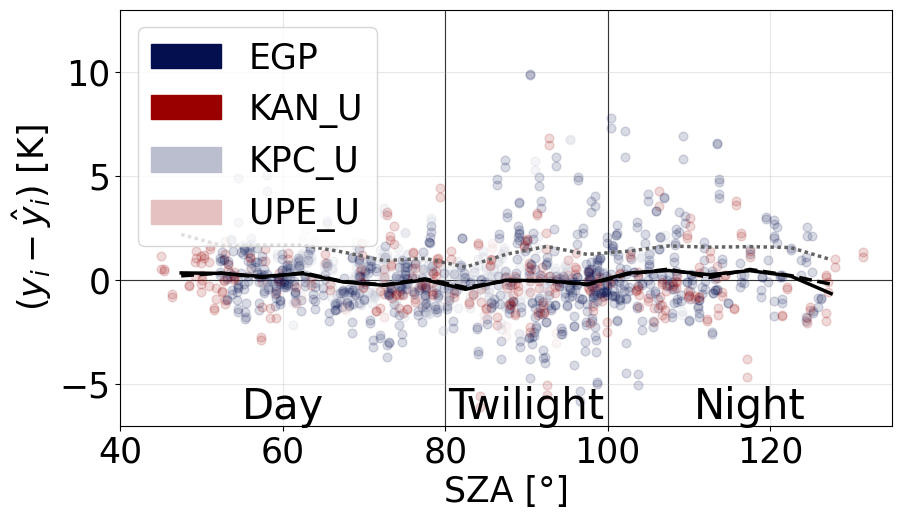

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


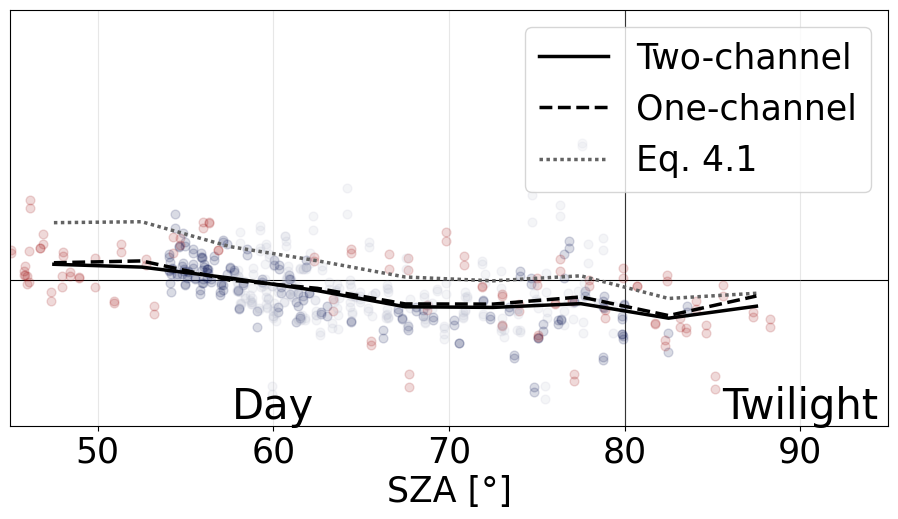

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── Layout and font settings ──────────────────────────────────────────────


# ── DTU colors ────────────────────────────────────────────────────────────
dtu_navy      = '#030F4F'
dtu_red       = '#990000'
dtu_grey      = '#DADADA'
dtu_grey_dark = '#636363'
phase2_blue   = '#babecf'
phase2_red    = '#e6c1c1'
black         = '#000000'

STATION_COLORS = {
    'EGP':   dtu_navy,
    'KAN_U': dtu_red,
    'KPC_U': phase2_blue,
    'UPE_U': phase2_red,
}

CH_STYLES = {
    'CH4+5': '-',
    'CH4':   '--',
}

# ── Pass 1: compute global y-limits across both datasets ──────────────────
all_residuals = []

for test_df in [df_test_2021, df_test_2025]:
    for feat_set in [SW_FEATS, SW_FEATS_CH4]:
        te_clean = test_df[feat_set + [TARGET, 'station_id']].dropna().copy()
        _, _, _, gbm_model = train_ngb(feat_set, SEED, test_df=test_df)
        mean_yp = gbm_model.predict(te_clean[feat_set].values.astype(float))
        all_residuals.append(te_clean[TARGET].values - mean_yp)

    algo_cols = ['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle', TARGET]
    te_algo = test_df[algo_cols].dropna().copy()
    T11   = te_algo['lev1_channel4'].values
    T12   = te_algo['lev1_channel5'].values
    sec_t = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
    yp_eq31 = (retrievals['algo2'][0] + retrievals['algo2'][1]*T11
               + retrievals['algo2'][2]*T12
               + retrievals['algo2'][3]*(T11-T12)*(sec_t-1))
    all_residuals.append(te_algo[TARGET].values - yp_eq31)

all_residuals = np.concatenate(all_residuals)
global_ymin = np.floor(np.nanmin(all_residuals))
global_ymax = np.ceil(np.nanmax(all_residuals))

# ── Pass 2: plot each figure ──────────────────────────────────────────────
for test_df, set_label, show_yaxis, legend_type in [
    (df_test_2021, '2021 bimonthly test', True,  'stations'),
    (df_test_2025, '2025 holdout',        False, 'models'),
]:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))

    for ch_label, feat_set in [
        ('CH4+5', SW_FEATS),
        ('CH4',   SW_FEATS_CH4),
    ]:
        te_clean = test_df[feat_set + [TARGET, 'station_id']].dropna().copy()
        te_clean['lev1_sunzenith_angle'] = test_df.loc[te_clean.index, 'lev1_sunzenith_angle']

        _, _, _, gbm_model = train_ngb(feat_set, SEED, test_df=test_df)
        mean_yp = gbm_model.predict(te_clean[feat_set].values.astype(float))

        te_clean['residual'] = te_clean[TARGET].values - mean_yp
        te_clean['sza']      = te_clean['lev1_sunzenith_angle']

        sza_min_ch = np.floor(te_clean['sza'].min() / 5) * 5
        sza_max_ch = np.ceil(te_clean['sza'].max() / 5) * 5

        # ── Scatter ───────────────────────────────────────────────────────
        for station, color in STATION_COLORS.items():
            mask = te_clean['station_id'] == station
            if mask.sum() == 0:
                continue
            ax.scatter(
                te_clean.loc[mask, 'sza'],
                te_clean.loc[mask, 'residual'],
                color=color, alpha=0.15, s=40, zorder=2
            )

        # ── Binned mean ± 1σ for GBM ──────────────────────────────────────
        bins = np.arange(sza_min_ch, sza_max_ch + 5, 5)
        bin_means, bin_stds, bin_centers = [], [], []
        for lo, hi in zip(bins[:-1], bins[1:]):
            mask = (te_clean['sza'] >= lo) & (te_clean['sza'] < hi)
            if mask.sum() > 5:
                bin_means.append(te_clean.loc[mask, 'residual'].mean())
                bin_stds.append(te_clean.loc[mask, 'residual'].std())
                bin_centers.append((lo + hi) / 2)
        bin_means   = np.array(bin_means)
        bin_stds    = np.array(bin_stds)
        bin_centers = np.array(bin_centers)

        #if ch_label == 'CH4':
        #    ax.fill_between(bin_centers,
        #                    bin_means - bin_stds,
        #                    bin_means + bin_stds,
        #                    alpha=0.10, color='k', zorder=1)

        ax.plot(bin_centers, bin_means, color='k', lw=2.5,
                ls=CH_STYLES[ch_label], zorder=4, label=f'GBM {ch_label} mean')

    # ── Eq. 3.1 binned mean ───────────────────────────────────────────────
    algo_cols = ['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle', TARGET]
    te_algo = test_df[algo_cols].dropna().copy()
    te_algo['lev1_sunzenith_angle'] = test_df.loc[te_algo.index, 'lev1_sunzenith_angle']
    te_algo['sza'] = te_algo['lev1_sunzenith_angle']

    T11    = te_algo['lev1_channel4'].values
    T12    = te_algo['lev1_channel5'].values
    sec_t  = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
    y_algo = te_algo[TARGET].values

    yp_eq31 = (retrievals['algo2'][0] + retrievals['algo2'][1]*T11
               + retrievals['algo2'][2]*T12
               + retrievals['algo2'][3]*(T11-T12)*(sec_t-1))
    te_algo['residual_eq31'] = y_algo - yp_eq31

    sza_algo_min = np.floor(te_algo['sza'].min() / 5) * 5
    sza_algo_max = np.ceil(te_algo['sza'].max() / 5) * 5
    bins_algo    = np.arange(sza_algo_min, sza_algo_max + 5, 5)

    eq31_bin_means, eq31_bin_centers = [], []
    for lo, hi in zip(bins_algo[:-1], bins_algo[1:]):
        mask = (te_algo['sza'] >= lo) & (te_algo['sza'] < hi)
        if mask.sum() > 5:
            eq31_bin_means.append(te_algo.loc[mask, 'residual_eq31'].mean())
            eq31_bin_centers.append((lo + hi) / 2)
    ax.plot(eq31_bin_centers, eq31_bin_means,
            color=dtu_grey_dark, lw=2.5, ls=(0, (1, 1)),
            zorder=3, label='Eq. 4.1')

    # ── Axes ──────────────────────────────────────────────────────────────
    sza_min = np.floor(test_df['lev1_sunzenith_angle'].min() / 5) * 5
    sza_max = np.ceil(test_df['lev1_sunzenith_angle'].max() / 5) * 5

    ax.axvline(80,  color='k', lw=0.8, ls='-', zorder=1)
    ax.axvline(100, color='k', lw=0.8, ls='-', zorder=1)
    ax.axhline(0,   color='k', lw=0.8, ls='-', zorder=1)

    ax.set_xlabel('SZA [°]')
    ax.set_xlim(sza_min, sza_max)
    ax.set_ylim(global_ymin, global_ymax)
    ax.grid(alpha=0.3, zorder=0)

    if show_yaxis:
        ax.set_ylabel(r'$(y_i - \hat{y}_i)$ [K]')
    else:
        ax.set_ylabel('')
        ax.yaxis.set_visible(False)

    ymin = ax.get_ylim()[0]
    if sza_min < 80:
        ax.text(min(60, (sza_min + 80) / 2), ymin * 0.95,
                'Day', ha='center', fontsize=30, color='k')
    if sza_max > 80:
        ax.text(90, ymin * 0.95,
                'Twilight', ha='center', fontsize=30, color='k')
    if sza_max > 100:
        ax.text(min(140, (100 + sza_max) / 2), ymin * 0.95,
                'Night', ha='center', fontsize=30, color='k')

    # ── Legend ────────────────────────────────────────────────────────────
    station_handles = [mpatches.Patch(color=c, label=s)
                       for s, c in STATION_COLORS.items()]
    model_handles = [
        plt.Line2D([0], [0], color='k', lw=2.5, ls='-',
                   label=r'Two-channel'),
        plt.Line2D([0], [0], color='k', lw=2.5, ls='--',
                   label=r'One-channel'),
        #mpatches.Patch(color='k', alpha=0.10,
        #               label='One-channel ±1σ'),
        plt.Line2D([0], [0], color=dtu_grey_dark, lw=2.5,
                   ls=(0, (1, 1)), label='Eq. 4.1'),
    ]

    if legend_type == 'stations':
        ax.legend(handles=station_handles,
                  fontsize=25, loc='upper left', title_fontsize=30)
    else:
        ax.legend(handles=model_handles,
                  fontsize=25, loc='upper right', title_fontsize=30)

    plt.tight_layout()
    plt.show()

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


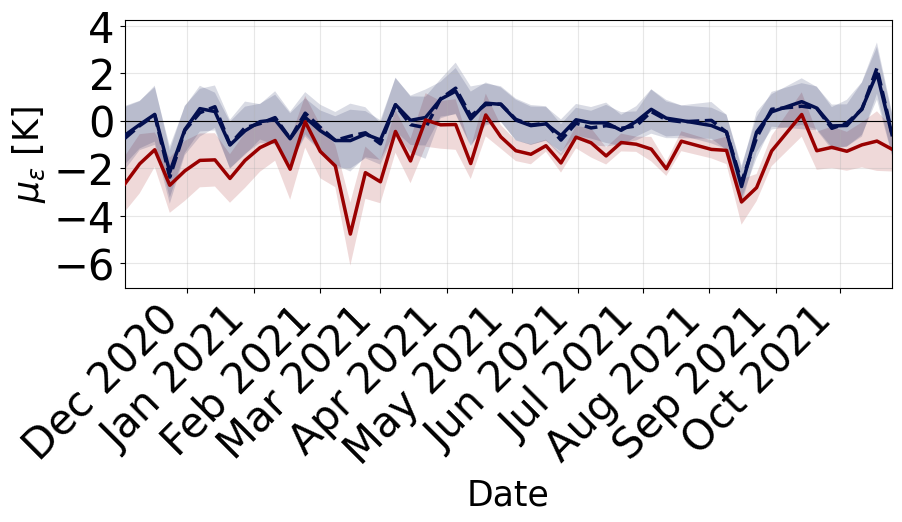

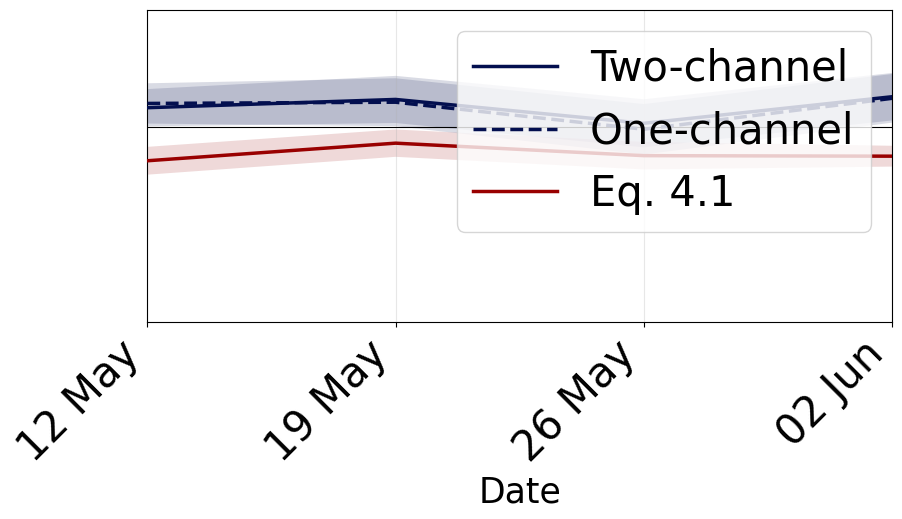

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── DTU colours (guarded so the cell runs standalone) ──────────────────────
dtu_blue = globals().get('dtu_blue', '#2F70AF')
dtu_red  = globals().get('dtu_red',  '#990000')
dtu_navy = globals().get('dtu_navy', '#030F4F')

# Brighter fills for the translucent bands (dark colours wash to grey at low alpha)
_BAND_BLUE = dtu_navy       # light enough to read as blue under transparency
_BAND_RED  = dtu_red      # brighter than dtu_red so the band reads as red

# ── Layout and font settings ──────────────────────────────────────────────
textwidth_in = 6.38
plt.rcParams.update({
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "legend.fontsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
})

# ── Binning controls ───────────────────────────────────────────────────────
FREQ  = 'W'    # 'D' daily, 'W' weekly, '2W' fortnightly, 'M' monthly
MIN_N = 3      # drop bins with fewer than this many matchups (suppresses thin-week spikes)

# ── Classical total uncertainty (unctot) lookup from the v2 match-up file ───
CLASS_UNC_COL = 'total_uncertainty'
with open('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv') as _f:
    _cols = [c.strip() for c in _f.readline().strip().strip('"').split(',')]
_df_v2 = pd.read_csv('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv',
                     skiprows=1, header=None, names=_cols)
_unc_lookup = (_df_v2[['time', 'station_id', 'unctot']]
               .rename(columns={'time': 'lev1_obstime', 'unctot': CLASS_UNC_COL})
               .copy())
_unc_lookup['lev1_obstime'] = pd.to_datetime(_unc_lookup['lev1_obstime'], errors='coerce').dt.round('s')
_unc_lookup['station_id']   = _unc_lookup['station_id'].astype(str).str.strip()
_unc_lookup = _unc_lookup.dropna(subset=['lev1_obstime', 'station_id']).drop_duplicates(
    ['lev1_obstime', 'station_id'])

def _attach_class_unc(df):
    d = df.copy()
    if CLASS_UNC_COL in d.columns:
        return d
    d['lev1_obstime'] = pd.to_datetime(d['lev1_obstime'], errors='coerce').dt.round('s')
    d['station_id']   = d['station_id'].astype(str).str.strip()
    return d.merge(_unc_lookup, on=['lev1_obstime', 'station_id'], how='left')

# Bias convention: y_pred - y_true -> negative = prediction colder than reference.
def _bias(y_true, y_pred):
    return y_pred - y_true

def _bin_key(dt):
    if FREQ == 'D':
        return dt.dt.floor('D')
    return dt.dt.to_period(FREQ).apply(lambda r: r.start_time)

def _binned_biases(test_df):
    test_df = _attach_class_unc(test_df)
    test_df['datetime'] = pd.to_datetime(test_df['lev1_obstime'])
    test_df['bin']      = _bin_key(test_df['datetime'])

    def _ngb_series(feats):
        te = test_df[feats + [TARGET]].dropna().copy()
        te['bin'] = test_df.loc[te.index, 'bin']
        _, _, _, gbm = train_ngb(feats, SEED, test_df=test_df)
        X = te[feats].values.astype(float)
        te['residual'] = _bias(te[TARGET].values, gbm.predict(X))
        te['sigma']    = gbm.pred_dist(X).scale
        grp  = te.groupby('bin')
        keep = grp.size() >= MIN_N
        return grp['residual'].mean()[keep], grp['sigma'].mean()[keep]

    bias_ch45, sig_ch45 = _ngb_series(SW_FEATS)
    bias_ch4,  sig_ch4  = _ngb_series(SW_FEATS_CH4)

    # ── Eq. 4.1 (classical): bias + weekly-mean unctot band ────────────────
    # drop on algo_cols AND unctot together, so the bias line and its
    # uncertainty band are computed from the *same* rows in every bin.
    algo_cols = ['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle', TARGET]
    has_unc = CLASS_UNC_COL in test_df.columns
    if has_unc:
        te_algo = test_df[algo_cols + [CLASS_UNC_COL]].dropna().copy()
    else:
        te_algo = test_df[algo_cols].dropna().copy()
    te_algo['bin'] = test_df.loc[te_algo.index, 'bin']
    T11   = te_algo['lev1_channel4'].values
    T12   = te_algo['lev1_channel5'].values
    sec_t = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
    yp_eq41 = (retrievals['algo2'][0] + retrievals['algo2'][1]*T11
               + retrievals['algo2'][2]*T12
               + retrievals['algo2'][3]*(T11-T12)*(sec_t-1))
    te_algo['residual'] = _bias(te_algo[TARGET].values, yp_eq41)
    grp  = te_algo.groupby('bin')
    keep = grp.size() >= MIN_N
    bias_eq41 = grp['residual'].mean()[keep]
    sig_eq41  = (grp[CLASS_UNC_COL].mean()[keep] if has_unc else None)

    return bias_ch45, sig_ch45, bias_ch4, sig_ch4, bias_eq41, sig_eq41

# ── Pre-compute both panels, then derive shared y-limits ───────────────────
panels = [
    (df_test_2021, '2021 bimonthly test', True),
    (df_test_2025, '2025 holdout',        False),
]
results = [(td, lbl, show, *_binned_biases(td)) for td, lbl, show in panels]

all_vals = []
for *_, b45, s45, b4, s4, beq, seq in results:
    all_vals += [b45.values + s45.values, b45.values - s45.values,
                 b4.values  + s4.values,  b4.values  - s4.values]
    if seq is not None:
        all_vals += [beq.values + seq.values, beq.values - seq.values]
    else:
        all_vals += [beq.values]
all_vals = np.concatenate(all_vals)
pad = 0.10 * (all_vals.max() - all_vals.min())
global_ymin = all_vals.min() - pad
global_ymax = all_vals.max() + pad

# Band alpha
_BAND_ALPHA = 0.15

# ── Plot (two separate figures) ─────────────────────────────────────────────
for test_df, set_label, show_yaxis, bias_ch45, sig_ch45, bias_ch4, sig_ch4, bias_eq41, sig_eq41 in results:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))

    # ── bands ──────────────────────────────────────────────────────────────
    if sig_eq41 is not None:
        ax.fill_between(bias_eq41.index, bias_eq41 - sig_eq41, bias_eq41 + sig_eq41,
                        facecolor=_BAND_RED, alpha=_BAND_ALPHA, lw=0, zorder=1)
    ax.fill_between(bias_ch45.index, bias_ch45 - sig_ch45, bias_ch45 + sig_ch45,
                    facecolor=_BAND_BLUE, alpha=_BAND_ALPHA, lw=0, zorder=1)
    ax.fill_between(bias_ch4.index, bias_ch4 - sig_ch4, bias_ch4 + sig_ch4,
                    facecolor=_BAND_BLUE, alpha=_BAND_ALPHA, lw=0, zorder=1)

    # ── lines ──────────────────────────────────────────────────────────────
    ax.plot(bias_ch45.index, bias_ch45.values,
            color=dtu_navy, lw=2.5, ls='-',  zorder=3, label='Two-channel')
    ax.plot(bias_ch4.index,  bias_ch4.values,
            color=dtu_navy, lw=2.5, ls='--', zorder=3, label='One-channel')
    ax.plot(bias_eq41.index, bias_eq41.values,
            color=dtu_red,  lw=2.5, ls='-', zorder=3, label='Eq. 4.1')

    ax.axhline(0, color='k', lw=0.8, ls='-', zorder=2)
    ax.set_xlabel('Date')
    ax.set_xlim(bias_ch45.index.min(), bias_ch45.index.max())
    ax.set_ylim(global_ymin, global_ymax)
    ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=6, steps=[1, 2, 2.5, 5, 10]))
    ax.grid(alpha=0.3, zorder=0)

    if show_yaxis:
        ax.set_ylabel(r'$\mu_\varepsilon$ [K]')
    else:
        ax.set_ylabel('')
        ax.yaxis.set_visible(False)
        ax.legend(fontsize=30, loc='upper right', frameon=True)
    if '2025' in set_label:
        ax.xaxis.set_major_locator(plt.matplotlib.dates.DayLocator(interval=7))  # every 7 days
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%d %b'))
    else:
        ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator()) # Every month
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    plt.tight_layout()
    plt.show()

Using passed validation data to check for early stopping.


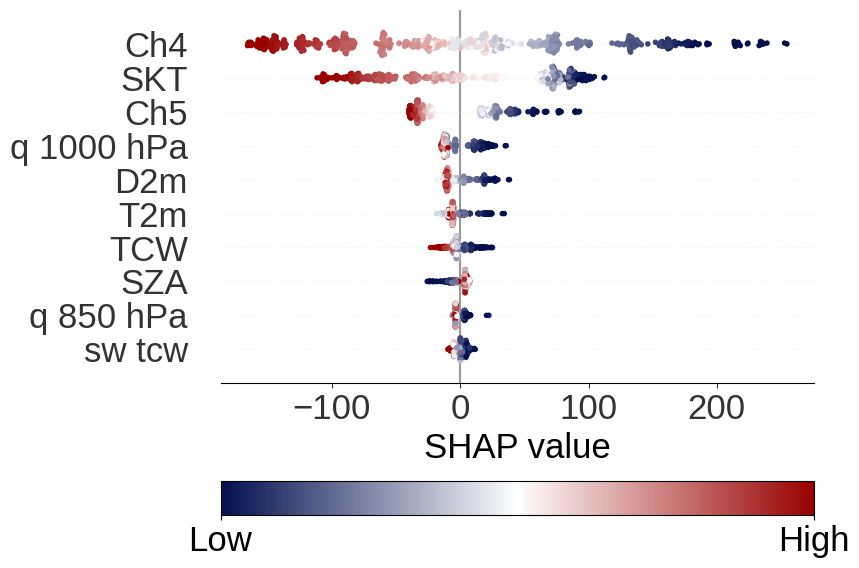

Using passed validation data to check for early stopping.


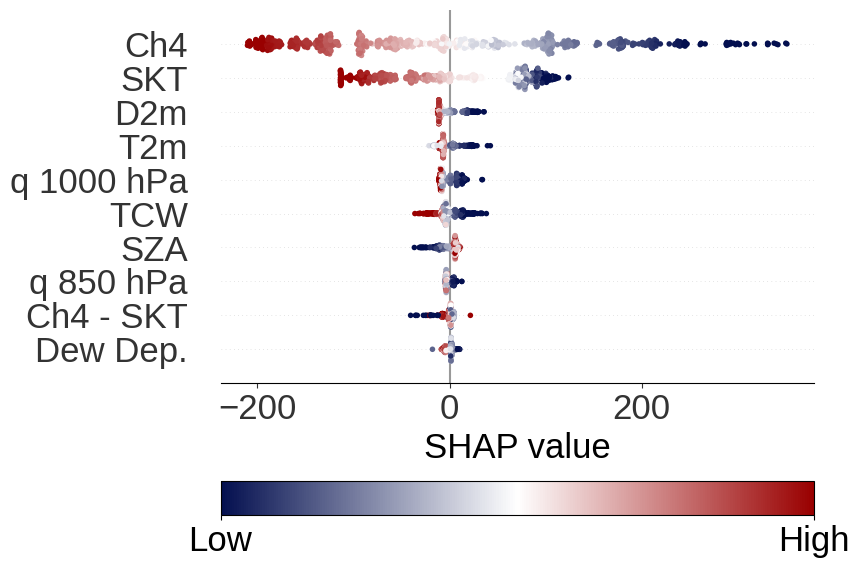

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib

# ── DTU color scheme ──────────────────────────────────────────────────────
matplotlib.rcParams['font.family'] = 'Liberation Sans'

dtu_navy = '#030F4F'
dtu_red  = '#990000'
white    = '#ffffff'

dtu_coolwarm_cmap = LinearSegmentedColormap.from_list(
    "dtu_coolwarm", [dtu_navy, white, dtu_red])

# ── Layout ────────────────────────────────────────────────────────────────
textwidth_in = 6.38
fs           = 25

plt.rcParams.update({
    "font.size":       fs,
    "axes.labelsize":  fs,
    "axes.titlesize":  fs,
    "legend.fontsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
})

FEATURE_NAMES = {
    'lev1_sunzenith_angle':  'SZA',
    'lev1_satzenith_angle':  'VZA',
    'lev1_channel4':         'Ch4',
    'lev1_channel5':         'Ch5',
    'nwp_skt':               'SKT',
    'nwp_t2m':               'T2m',
    'nwp_d2m':               'D2m',
    'nwp_tcc':               'TCC',
    'nwp_tcw':               'TCW',
    'nwp_u10':               'U10',
    'nwp_v10':               'V10',
    'nwp_wind':              'Wind Speed',
    'ch4_minus_skt':         'Ch4 - SKT',
    'ch4_minus_t2m':         'Ch4 - T2m',
    'ch4_minus_d2m':         'Ch4 - D2m',
    'dew_depression':        'Dew Dep.',
    'nwp_q_1000_hPa':        'q 1000 hPa',
    'nwp_q_850_hPa':         'q 850 hPa',
    'nwp_q_700_hPa':         'q 700 hPa',
    'nwp_q_500_hPa':         'q 500 hPa',
    'nwp_q_300_hPa':         'q 300 hPa',
    'nwp_q_200_hPa':         'q 200 hPa',
    'nwp_q_100_hPa':         'q 100 hPa',
    'nwp_q_50_hPa':          'q 50 hPa',
    'nwp_t_1000_hPa':        'T 1000 hPa',
    'nwp_t_850_hPa':         'T 850 hPa',
    'nwp_t_700_hPa':         'T 700 hPa',
    'nwp_t_500_hPa':         'T 500 hPa',
    'nwp_t_300_hPa':         'T 300 hPa',
    'nwp_t_200_hPa':         'T 200 hPa',
    'nwp_t_100_hPa':         'T 100 hPa',
    'nwp_t_50_hPa':          'T 50 hPa',
}

# ── SHAP for NGBoost: aggregate over loc (mean) base learners ─────────────
# NGBoost stores base_models as a list of (loc_tree, scale_tree) pairs.
# We sum SHAP values across all loc trees to get the composite attribution.
for feats, ch in [(SW_FEATS, 'CH4+5'), (SW_FEATS_CH4, 'CH4')]:

    te  = df_test_2021[feats + [TARGET]].dropna().copy()
    Xte = te[feats].values.astype(float)
    _, _, _, ngb = train_ngb(feats, SEED, test_df=df_test_2021)

    # Sum SHAP values across all loc base models
    shap_values = np.zeros_like(Xte)
    for loc_tree, _ in ngb.base_models:
        explainer    = shap.TreeExplainer(loc_tree)
        shap_values += explainer.shap_values(Xte)

    # Top 10 by mean absolute SHAP
    mean_abs    = np.abs(shap_values).mean(axis=0)
    top10_idx   = np.argsort(mean_abs)[-10:]
    top10_feats = [feats[i] for i in top10_idx]
    top10_shap  = shap_values[:, top10_idx]
    top10_X     = Xte[:, top10_idx]

    top10_feats_display = [FEATURE_NAMES.get(f, f.replace('_', ' '))
                           for f in top10_feats]

    # ── Render ────────────────────────────────────────────────────────────
    shap.summary_plot(
        top10_shap,
        top10_X,
        feature_names=top10_feats_display,
        plot_type='dot',
        show=False,
        plot_size=(textwidth_in * 1.5, textwidth_in * 0.9),
        max_display=10,
    )

    fig = plt.gcf()
    main_ax = fig.axes[0]
    main_ax.set_xlabel('SHAP value', fontsize=fs)
    main_ax.tick_params(axis='x', labelsize=fs)
    main_ax.tick_params(axis='y', labelsize=fs)

    # ── Recolour collections and grab mappable ────────────────────────────
    mappable = None
    for coll in main_ax.collections:
        arr = coll.get_array()
        if arr is not None and len(arr) > 0:
            coll.set_cmap(dtu_coolwarm_cmap)
            if mappable is None:
                mappable = coll
    for im in main_ax.get_images():
        im.set_cmap(dtu_coolwarm_cmap)

    # ── Remove existing vertical colorbar axes ────────────────────────────
    for ax_ in fig.axes[1:]:
        ax_.remove()

    main_ax.set_position([0.35, 0.28, 0.62, 0.65])

    cbar_ax = fig.add_axes([0.35, 0.05, 0.62, 0.06])

    norm = mcolors.Normalize(vmin=mappable.norm.vmin, vmax=mappable.norm.vmax)
    sm   = cm.ScalarMappable(cmap=dtu_coolwarm_cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_ticks([norm.vmin, norm.vmax])
    cbar.set_ticklabels(['Low', 'High'], fontsize=fs)
    cbar.ax.tick_params(labelsize=fs)

    plt.show()

Using passed validation data to check for early stopping.

CH4+5 | 2021
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP           390   +0.036    1.812    0.951 K
  KAN_U         157   -0.057    1.510    0.883 K
  KPC_U         121   +0.325    1.328    0.764 K
  UPE_U          18   -0.703    1.327    0.817 K
  ----------------------------------------------
  Overall       686   +0.046    1.664 K


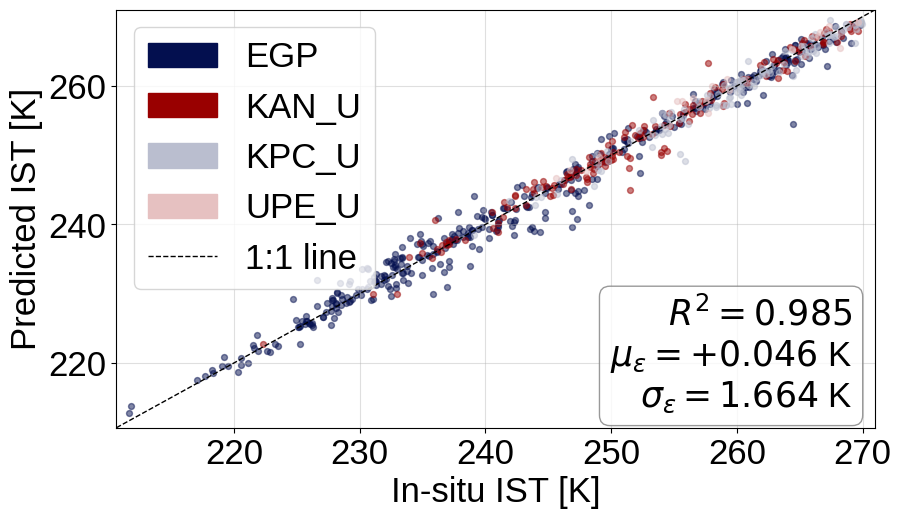

Using passed validation data to check for early stopping.

CH4+5 | 2025
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP            91   -0.535    1.660    0.946 K
  KAN_U          58   -0.421    1.881    0.700 K
  KPC_U         129   -0.683    1.388    0.833 K
  ----------------------------------------------
  Overall       278   -0.580    1.589 K


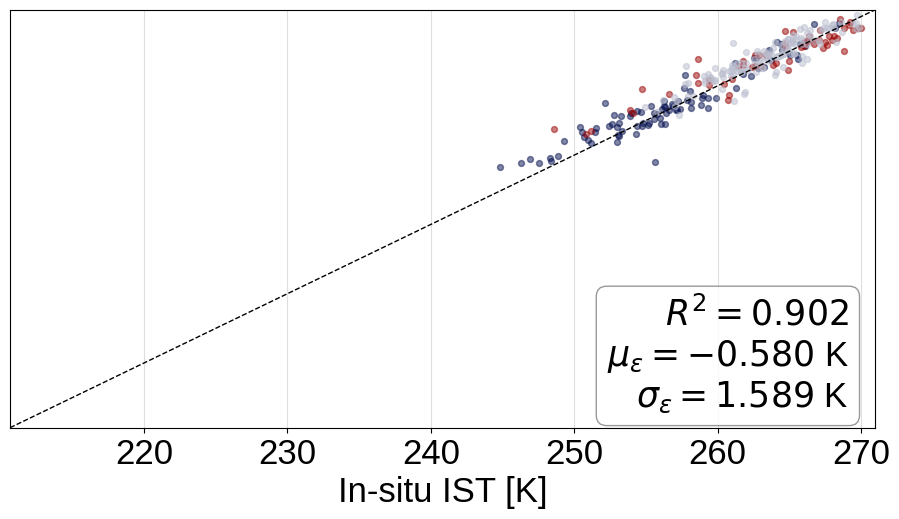

Using passed validation data to check for early stopping.

CH4 | 2021
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP           390   +0.077    1.882    1.008 K
  KAN_U         157   -0.078    1.565    0.920 K
  KPC_U         121   +0.280    1.331    0.782 K
  UPE_U          18   -0.737    1.474    0.854 K
  ----------------------------------------------
  Overall       686   +0.056    1.722 K


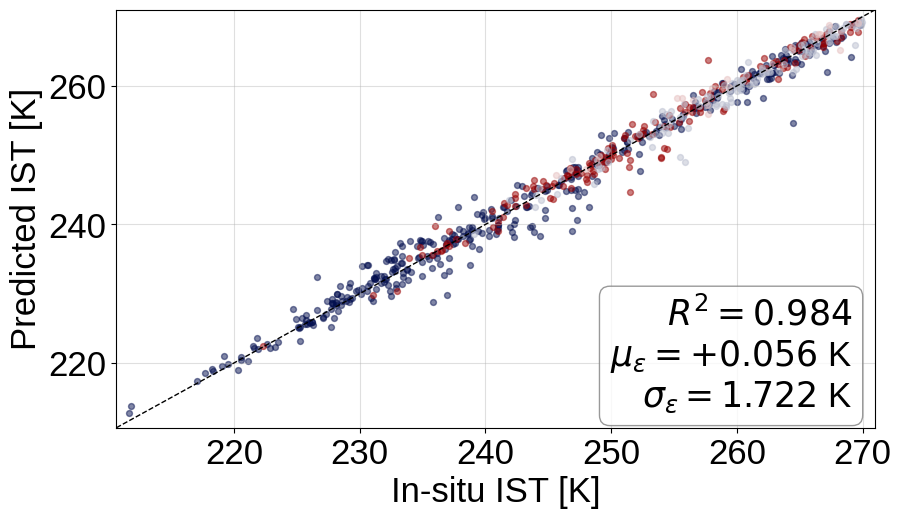

Using passed validation data to check for early stopping.

CH4 | 2025
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP            91   -0.414    1.629    0.948 K
  KAN_U          58   -0.225    1.861    0.755 K
  KPC_U         129   -0.603    1.488    0.888 K
  ----------------------------------------------
  Overall       278   -0.462    1.618 K


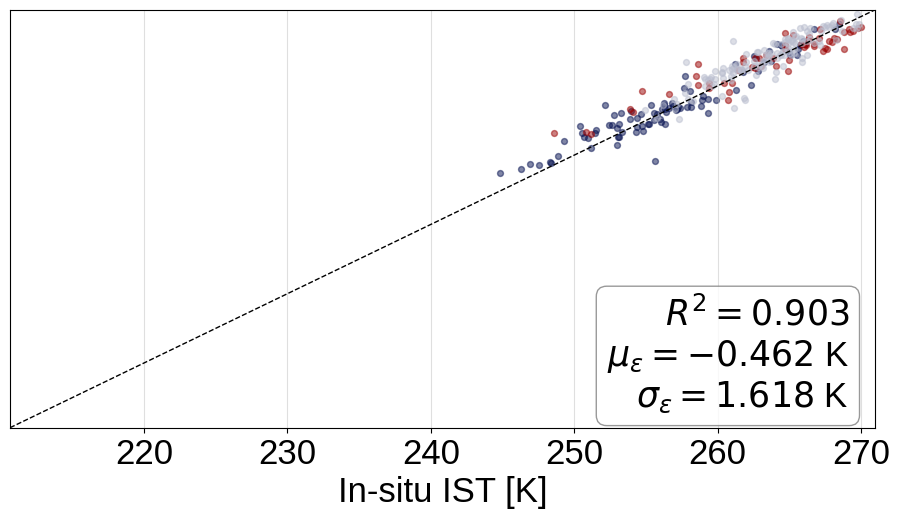

In [ ]:
STATIONS_2021 = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']
STATIONS_2025 = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']

STATION_COLORS_ALL = {
    **STATION_COLORS,
    'SCO_U': '#2ca02c',
    'QAS_U': '#ff7f0e',
}

# ── Compute global axis limits across both years ──────────────────────────
all_y = []
for test_df in [df_test_2021, df_test_2025]:
    for feats in [SW_FEATS, SW_FEATS_CH4]:
        te = test_df[feats + [TARGET, 'station_id']].dropna().copy()
        all_y.append(te[TARGET].values)
all_y = np.concatenate(all_y)
global_lim = (all_y.min() - 1, all_y.max() + 1)

# ── Plot and statistics ───────────────────────────────────────────────────
for (feats, label), test_df, station_filter, show_yaxis, show_legend, set_label in [
    ((SW_FEATS,     'CH4+5'), df_test_2021, STATIONS_2021, True,  True,  '2021'),
    ((SW_FEATS,     'CH4+5'), df_test_2025, STATIONS_2025, False, False, '2025'),
    ((SW_FEATS_CH4, 'CH4'),   df_test_2021, STATIONS_2021, True,  False, '2021'),
    ((SW_FEATS_CH4, 'CH4'),   df_test_2025, STATIONS_2025, False, False, '2025'),
]:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))

    _, _, _, gbm = train_ngb(feats, SEED, test_df=test_df)
    te = test_df[feats + [TARGET, 'station_id']].dropna().copy()
    te = te[te['station_id'].isin(station_filter)]
    te['y_pred'] = gbm.predict(te[feats].values.astype(float))

    legend_handles = []

    print(f"\n{'='*60}")
    print(f"{label} | {set_label}")
    print(f"  {'Station':<10} {'N':>6} {'Bias':>8} {'σ_ε':>8} {'σ_NGB':>8}")
    print(f"  {'-'*46}")

    for st in station_filter:
        color = STATION_COLORS_ALL[st]
        mask  = te['station_id'] == st
        if mask.sum() == 0:
            continue

        y_te_st   = te.loc[mask, TARGET].values
        y_pred_st = te.loc[mask, 'y_pred'].values
        res_st    = y_te_st - y_pred_st
        bias      = res_st.mean()
        sigma     = res_st.std(ddof=1)

        dist_st      = gbm.pred_dist(te.loc[mask, feats].values.astype(float))
        sigma_ngb_st = float(dist_st.params['scale'].mean())

        print(f"  {st:<10} {mask.sum():>6} {bias:>+8.3f} {sigma:>8.3f} {sigma_ngb_st:>8.3f} K")

        ax.scatter(y_te_st, y_pred_st, alpha=0.50, s=18, color=color)
        legend_handles.append(mpatches.Patch(color=color, label=st))

    res_all = te[TARGET].values - te['y_pred'].values
    print(f"  {'-'*46}")
    print(f"  {'Overall':<10} {len(te):>6} {res_all.mean():>+8.3f} "
          f"{res_all.std(ddof=1):>8.3f} K")

    # ── Metrics: R², bias (μ_ε), residual std (σ_ε) ──
    ss_res = np.sum(res_all ** 2)
    ss_tot = np.sum((te[TARGET].values - te[TARGET].values.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot

    mu_eps    = res_all.mean()           # bias
    sigma_eps = res_all.std(ddof=1)      # residual standard deviation

    ax.text(0.97, 0.03,
            f"$R^2 = {r2:.3f}$\n"
            f"$\\mu_\\varepsilon = {mu_eps:+.3f}$ K\n"
            f"$\\sigma_\\varepsilon = {sigma_eps:.3f}$ K",
            transform=ax.transAxes, fontsize=fs,
            ha='right', va='bottom',
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.8))

    ax.plot(global_lim, global_lim, 'k--', lw=1)
    legend_handles.append(plt.Line2D([0], [0], color='k', lw=1, ls='--',
                                     label='1:1 line'))

    ax.set_xlim(global_lim)
    ax.set_ylim(global_lim)
    ax.set_xlabel('In-situ IST [K]', fontsize=fs)
    ax.tick_params(axis='both', labelsize=fs)
    ax.grid(alpha=0.4)

    if show_yaxis:
        ax.set_ylabel('Predicted IST [K]', fontsize=fs)
    else:
        ax.set_ylabel('')
        ax.yaxis.set_visible(False)

    if show_legend:
        ax.legend(handles=legend_handles, fontsize=fs, loc='upper left')

    plt.tight_layout()
    plt.show()

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


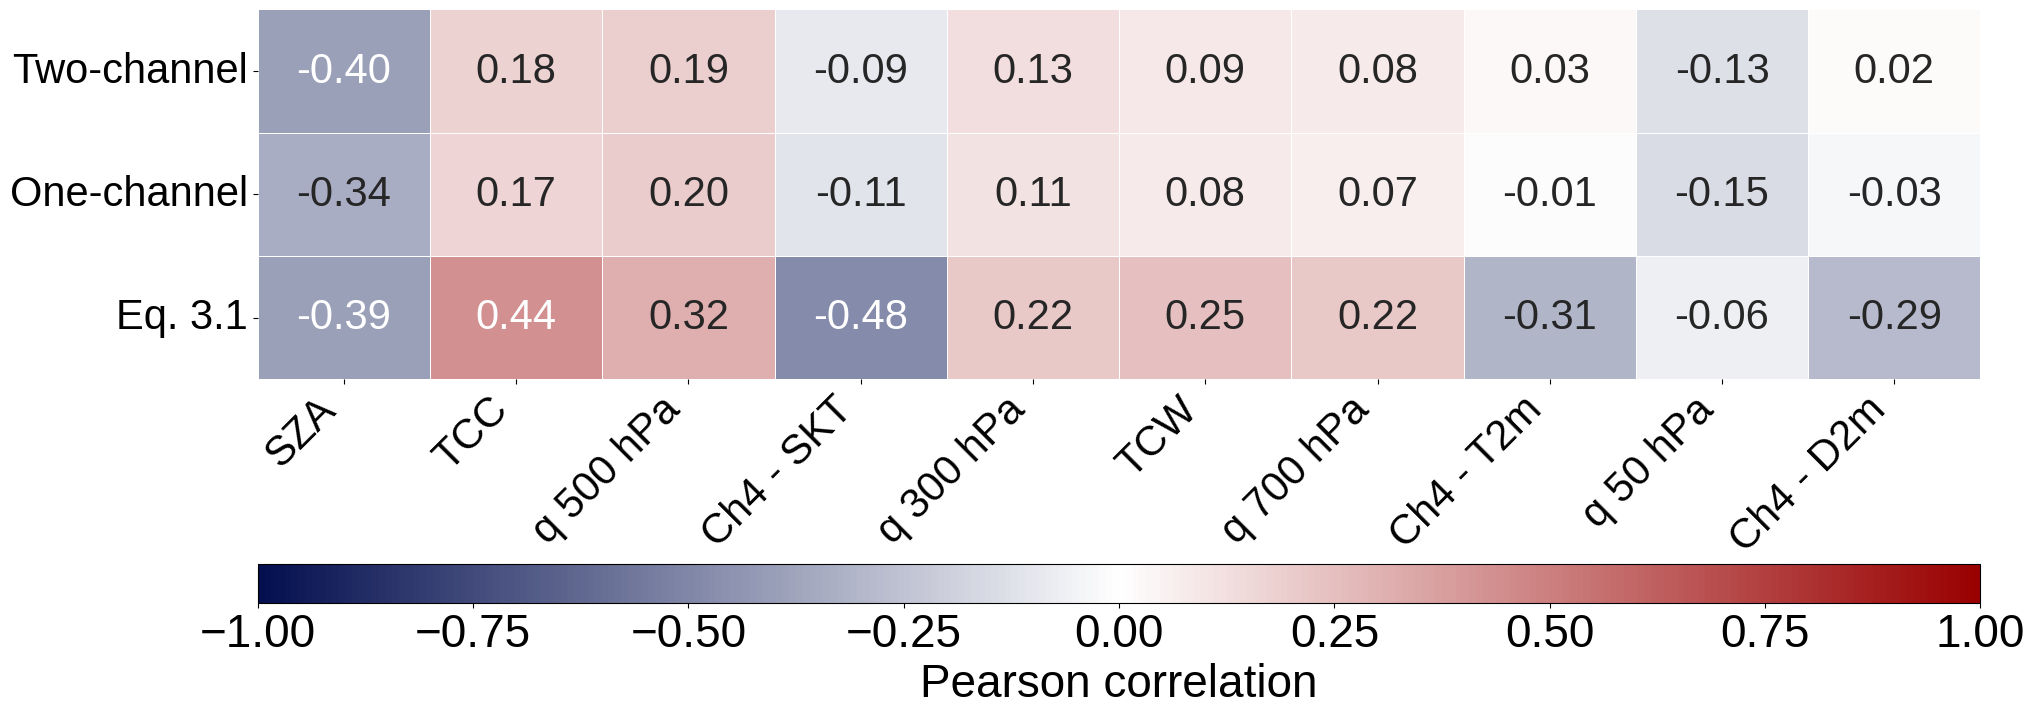

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib

matplotlib.rcParams['font.family'] = 'Liberation Sans'

# ── DTU color scheme ──────────────────────────────────────────────────────
dtu_navy  = '#030F4F'
dtu_red   = '#990000'
white     = '#ffffff'

dtu_coolwarm_cmap = LinearSegmentedColormap.from_list(
    "dtu_coolwarm", [dtu_navy, white, dtu_red])

# ── Layout and font settings ──────────────────────────────────────────────
textwidth_in = 6.38
plt.rcParams.update({
    "font.size": 30,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "legend.fontsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
})

# ── Human-readable feature names ─────────────────────────────────────────
FEATURE_NAMES = {
    'lev1_sunzenith_angle':  'SZA',
    'lev1_satzenith_angle':  'VZA',
    'lev1_channel4':         'Ch4 BT',
    'nwp_skt':               'SKT',
    'nwp_t2m':               'T2m',
    'nwp_d2m':               'D2m',
    'nwp_tcc':               'TCC',
    'nwp_tcw':               'TCW',
    'nwp_u10':               'U10',
    'nwp_v10':               'V10',
    'nwp_wind':              'Wind Speed',
    'ch4_minus_skt':         'Ch4 - SKT',
    'ch4_minus_t2m':         'Ch4 - T2m',
    'ch4_minus_d2m':         'Ch4 - D2m',
    'dew_depression':        'Dew Dep.',
    'nwp_q_1000_hPa':        'q 1000 hPa',
    'nwp_q_850_hPa':         'q 850 hPa',
    'nwp_q_700_hPa':         'q 700 hPa',
    'nwp_q_500_hPa':         'q 500 hPa',
    'nwp_q_300_hPa':         'q 300 hPa',
    'nwp_q_200_hPa':         'q 200 hPa',
    'nwp_q_100_hPa':         'q 100 hPa',
    'nwp_q_50_hPa':          'q 50 hPa',
    'nwp_t_1000_hPa':        'T 1000 hPa',
    'nwp_t_850_hPa':         'T 850 hPa',
    'nwp_t_700_hPa':         'T 700 hPa',
    'nwp_t_500_hPa':         'T 500 hPa',
    'nwp_t_300_hPa':         'T 300 hPa',
    'nwp_t_200_hPa':         'T 200 hPa',
    'nwp_t_100_hPa':         'T 100 hPa',
    'nwp_t_50_hPa':          'T 50 hPa',
}

# ── Compute residuals for all three models ────────────────────────────────
def get_residuals_and_features(feats, seed):
    _, _, _, gbm_model = train_ngb(feats, seed)
    te = df_test[feats + [TARGET]].dropna().copy()
    Xte = te[feats].values.astype(float)
    yte = te[TARGET].values.astype(float)
    yp  = gbm_model.predict(Xte)
    te['residual'] = yte - yp
    return te

df_ch45 = get_residuals_and_features(SW_FEATS,     SEED)
df_ch4  = get_residuals_and_features(SW_FEATS_CH4, SEED)

# ── Eq. 3.1 residuals ─────────────────────────────────────────────────────
te_algo = df_test[list(set(SW_FEATS_CH4 + [TARGET, 'lev1_satzenith_angle']))].dropna().copy()
T11   = te_algo['lev1_channel4'].values
T12   = df_test.loc[te_algo.index, 'lev1_channel5'].values
sec_t = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
te_algo['residual'] = te_algo[TARGET].values - (
    retrievals['algo2'][0] + retrievals['algo2'][1]*T11
    + retrievals['algo2'][2]*T12
    + retrievals['algo2'][3]*(T11-T12)*(sec_t-1))

# ── Correlations restricted to SW_FEATS_CH4 features only ────────────────
corr_ch45 = df_ch45[SW_FEATS_CH4 + ['residual']].corr()['residual'].drop('residual')
corr_ch4  = df_ch4[ SW_FEATS_CH4 + ['residual']].corr()['residual'].drop('residual')
corr_eq31 = te_algo[SW_FEATS_CH4 + ['residual']].corr()['residual'].drop('residual')

# ── Top 10 by mean absolute correlation across all three models ───────────
mean_abs_corr = (corr_ch45.abs() + corr_ch4.abs() + corr_eq31.abs()) / 3
top_feats = mean_abs_corr.nlargest(10).index.tolist()

corr_df = pd.DataFrame({
    'Two-channel': corr_ch45.reindex(top_feats),
    'One-channel': corr_ch4.reindex(top_feats),
    'Eq. 3.1':     corr_eq31.reindex(top_feats),
}).T

# ── Rename columns to human-readable names ────────────────────────────────
corr_df.columns = [FEATURE_NAMES.get(f, f.replace('_', ' ')) for f in corr_df.columns]

# ── Plot ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(textwidth_in * 3.0, textwidth_in * 1))

ax      = fig.add_axes([0.08, 0.35, 0.90, 0.58])   # heatmap
cbar_ax = fig.add_axes([0.08, -0, 0.90, 0.06])   # colorbar with more distance below xticks

sns.heatmap(
    corr_df,
    ax=ax,
    cmap=dtu_coolwarm_cmap,
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 30   },
    linewidths=0.4,
    cbar=False,
)

ax.set_xticklabels(ax.get_xticklabels(), fontsize=30, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=30, rotation=0)

# ── Colorbar ──────────────────────────────────────────────────────────────
norm = mcolors.Normalize(vmin=-1, vmax=1)
sm   = cm.ScalarMappable(cmap=dtu_coolwarm_cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson correlation', fontsize=33)
cbar.ax.tick_params(labelsize=33)

plt.show()

# Uncertainties

In [23]:
# ── Uncertainty Quantification — 2025 holdout only (NGBoost) ────────────
# NGBRegressor natively outputs a Normal predictive distribution.
# pred_dist(X).loc   = predicted mean
# pred_dist(X).scale = predicted std  (per-sample aleatoric uncertainty)
# 80% interval: loc ± Z_80 · scale   (Z_80 = Phi^{-1}(0.90) ≈ 1.282)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm as scipy_norm
from ngboost.distns import Normal

NOMINAL_COVERAGE = 0.80
NGB_SEED         = 42
Z_80             = scipy_norm.ppf(0.90)   # ≈ 1.282


def compute_uncertainty(feats, label, verbose=True):
    """
    NGBoost predictive distribution on 2025 holdout.
    Train on full df_train_2021; evaluate intervals on df_test_2025.
    """
    tr = df_train_2021[feats + [TARGET]].dropna()
    te = df_test_2025[ feats + [TARGET]].dropna()

    # ── Fit NGBRegressor ──────────────────────────────────────────────────
    print(f"  [{label}] fitting NGBRegressor...", end=' ', flush=True)
    ngb = NGBRegressor(
        Dist=Normal,
        Base=_make_base(NGB_MAX_DEPTH),
        n_estimators=NGB_N_ESTIMATORS,
        learning_rate=NGB_LEARNING_RATE,
        random_state=NGB_SEED,
        verbose=False,
        early_stopping_rounds=NGB_EARLY_STOP,
    )
    # Early stopping picks M* automatically using the held-out set.
    ngb.fit(tr[feats].values.astype(float),
            tr[TARGET].values.astype(float),
            X_val=te[feats].values.astype(float),
            Y_val=te[TARGET].values.astype(float))
    print("done.")

    # ── Predictive distribution on test set ───────────────────────────────
    te_dist = ngb.pred_dist(te[feats].values.astype(float))
    yte     = te[TARGET].values.astype(float)
    yp_med  = te_dist.loc
    yp_lo   = yp_med - Z_80 * te_dist.scale
    yp_hi   = yp_med + Z_80 * te_dist.scale

    covered = (yte >= yp_lo) & (yte <= yp_hi)
    width   = yp_hi - yp_lo

    def winkler(lo, hi, y, a=0.20):
        w  = hi - lo
        w += (2/a) * np.maximum(lo - y, 0)
        w += (2/a) * np.maximum(y - hi, 0)
        return w.mean()

    if verbose:
        print(f"\n{'='*57}")
        print(f"  {label}  —  2025 holdout")
        print(f"{'='*57}")
        print(f"  {'Nominal coverage (80%)':<30}  {'0.800':>8}")
        print(f"  {'Empirical coverage':<30}  {covered.mean():>8.3f}")
        print(f"  {'Mean interval width [K]':<30}  {width.mean():>8.3f}")
        print(f"  {'Median interval width [K]':<30}  {np.median(width):>8.3f}")
        print(f"  {'Winkler score (↓better)':<30}  {winkler(yp_lo, yp_hi, yte):>8.4f}")

        sza     = df_test_2025.loc[te.index, 'lev1_sunzenith_angle'].values.flatten()
        regimes = pd.cut(sza, bins=[-np.inf, 80, 100, np.inf],
                         labels=['Day', 'Twilight', 'Night'])
        print(f"\n  Coverage by SZA regime:")
        for regime in ['Day', 'Twilight', 'Night']:
            mask = (regimes == regime)
            if mask.sum() == 0: continue
            print(f"    {regime:<10} {covered[mask].mean():.3f}  (n={mask.sum():,})")

    return pd.DataFrame({
        'y_true':         yte,
        'y_pred_median':  yp_med,
        'y_pred_lower':   yp_lo,
        'y_pred_upper':   yp_hi,
        'interval_width': width,
        'uncertainty_k':  width / 2,        # ±K half-width
        'ngb_scale':      te_dist.scale,    # raw predicted std from NGBoost
        'residual':       yte - yp_med,
        'covered':        covered,
    })


# ── Run ───────────────────────────────────────────────────────────────────
unc_ch45 = compute_uncertainty(SW_FEATS,     'CH4+5')
unc_ch4  = compute_uncertainty(SW_FEATS_CH4, 'CH4')

  [CH4+5] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.

  CH4+5  —  2025 holdout
  Nominal coverage (80%)             0.800
  Empirical coverage                 0.465
  Mean interval width [K]            2.166
  Median interval width [K]          2.189
  Winkler score (↓better)           7.1771

  Coverage by SZA regime:
    Day        0.466  (n=264)
    Twilight   0.450  (n=20)
  [CH4] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.

  CH4  —  2025 holdout
  Nominal coverage (80%)             0.800
  Empirical coverage                 0.507
  Mean interval width [K]            2.254
  Median interval width [K]          2.271
  Winkler score (↓better)           7.1320

  Coverage by SZA regime:
    Day        0.515  (n=264)
    Twilight   0.400  (n=20)


In [24]:
# ── Build ngb_ch45 / ngb_ch4 DataFrames for the calibration plot ─────────
# The calibration plot below expects columns named exactly 'residual' and 'sigma'.
ngb_ch45 = unc_ch45.rename(columns={'ngb_scale': 'sigma'})[['residual', 'sigma']].copy()
ngb_ch4  = unc_ch4 .rename(columns={'ngb_scale': 'sigma'})[['residual', 'sigma']].copy()

print(f'ngb_ch45: {len(ngb_ch45):,} rows   '
      f'σ range: {ngb_ch45["sigma"].min():.3f}–{ngb_ch45["sigma"].max():.3f} K')
print(f'ngb_ch4 : {len(ngb_ch4):,} rows   '
      f'σ range: {ngb_ch4["sigma"].min():.3f}–{ngb_ch4["sigma"].max():.3f} K')

ngb_ch45: 284 rows   σ range: 0.291–1.649 K
ngb_ch4 : 284 rows   σ range: 0.349–2.026 K


In [25]:
# ── Calibration helpers (used by the NGBoost calibration plots) ──────────────
import numpy as np
import pandas as pd

def compute_binned_stats_by_sigma(df, bin_width=0.2, sigma_col="sigma", resid_col="residual"):
    """Bin rows by predicted sigma and summarise the residuals in each bin.
    Returns columns: bin_mid, bin_mean, std_residual, count."""
    d = df[[sigma_col, resid_col]].dropna().copy()
    if d.empty:
        return pd.DataFrame(columns=["bin_mid", "bin_mean", "std_residual", "count"])
    smax = float(d[sigma_col].max())
    edges = np.arange(0.0, smax + bin_width, bin_width)
    if len(edges) < 2:
        edges = np.array([0.0, smax + bin_width])
    d["_bin"] = pd.cut(d[sigma_col], bins=edges, include_lowest=True)
    g = d.groupby("_bin", observed=True)[resid_col]
    out = pd.DataFrame({
        "bin_mean":     g.mean(),
        "std_residual": g.std(ddof=1),
        "count":        g.count(),
    }).reset_index()
    out["bin_mid"] = out["_bin"].apply(lambda iv: iv.mid).astype(float)
    return out[["bin_mid", "bin_mean", "std_residual", "count"]].sort_values("bin_mid").reset_index(drop=True)

def optimal_lines(x_max, sigma):
    x = np.linspace(0, x_max, 100)
    return x, np.where(x<=0.2, sigma, sigma+(x-0.2)), np.where(x<=0.2, -sigma, -sigma-(x-0.2))

# 2025-holdout calibration inputs used by the plot cell
stats_ngb_ch45 = compute_binned_stats_by_sigma(ngb_ch45)
stats_ngb_ch4  = compute_binned_stats_by_sigma(ngb_ch4)
sigma_ch45 = float(ngb_ch45["residual"].std(ddof=1))
sigma_ch4  = float(ngb_ch4["residual"].std(ddof=1))

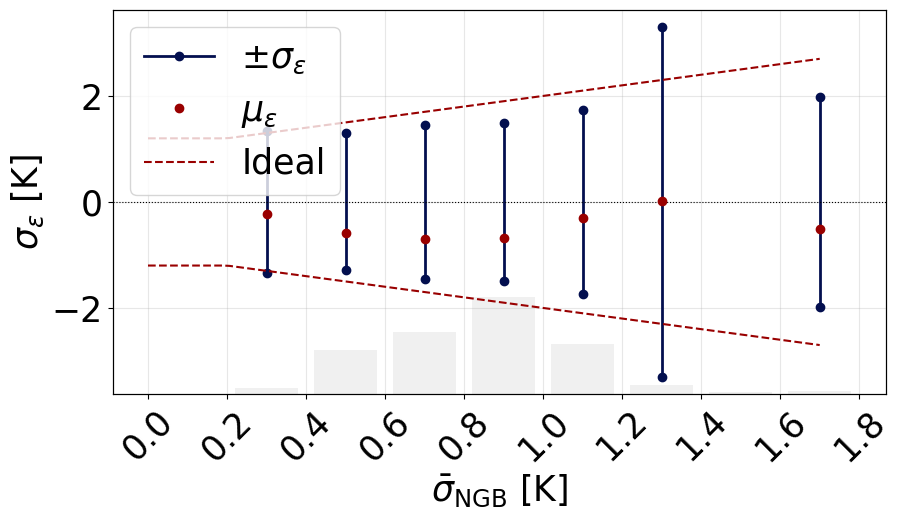

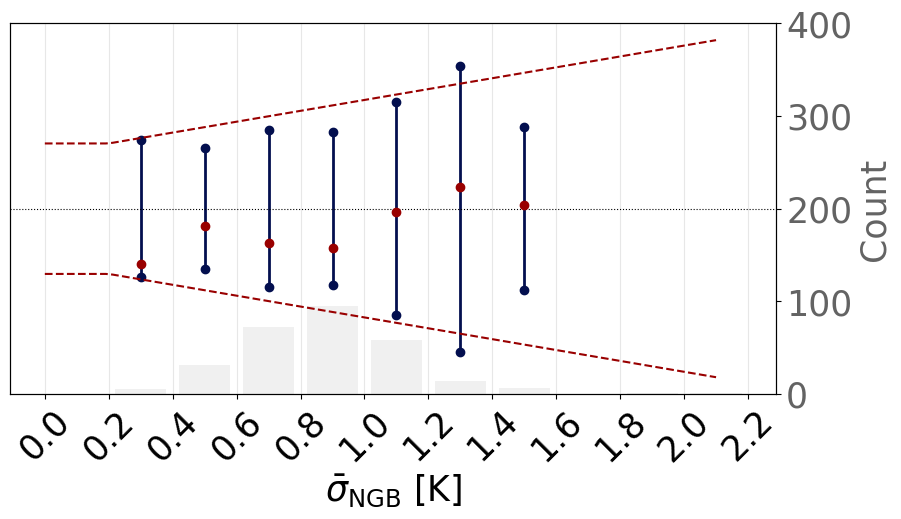

In [31]:
from matplotlib.lines import Line2D
def optimal_lines(x_max, sigma, start=1.2):
    x = np.linspace(0, x_max, 100)
    start = sigma if start is None else start
    return x, np.where(x <= 0.2, start, start + (x - 0.2)), np.where(x <= 0.2, -start, -start - (x - 0.2))

def plot_ngb_calibration(ax, stats, sigma, ylabel=True, show_legend=True, show_count_axis=False):
    x    = np.array(stats['bin_mid'].values,      dtype=float)
    yerr = np.array(stats['std_residual'].values,  dtype=float)
    mean = np.array(stats['bin_mean'].values,      dtype=float)
    n    = stats['count'].values

    # ── Background histogram of counts ───────────────────────────────────
    ax_hist = ax.twinx()
    bin_width = x[1] - x[0] if len(x) > 1 else 0.2
    ax_hist.bar(x, n, width=bin_width * 0.8, color=dtu_grey, alpha=0.4,
                zorder=1, align='center')
    ax_hist.set_ylim(0, 400) # change this range when running new counts!
    ax_hist.yaxis.set_visible(show_count_axis)
    if show_count_axis:
        ax_hist.set_ylabel('Count', color=dtu_grey_dark)
        ax_hist.tick_params(axis='y', labelcolor=dtu_grey_dark)

    # ── ±σ_ε bars and μ_ε dots ───────────────────────────────────────────
    for xc, std, mn, ni in zip(x, yerr, mean, n):
        if np.isnan(std) or ni < 3:
            continue
        ax.plot([xc, xc], [-std, std], color=dtu_navy, lw=2, zorder=2)
        ax.plot(xc,  std, 'o', color=dtu_navy, ms=6, zorder=3)
        ax.plot(xc, -std, 'o', color=dtu_navy, ms=6, zorder=3)
        ax.plot(xc,  mn,  'o', color=dtu_red,  ms=6, zorder=4)

    x_line, y_plus, y_minus = optimal_lines(x.max(), sigma)
    ax.plot(x_line,  y_plus,  color=dtu_red, ls='--', lw=1.5, zorder=3)
    ax.plot(x_line,  y_minus, color=dtu_red, ls='--', lw=1.5, zorder=3)

    ax.axhline(0, color='k', lw=0.8, ls=':', zorder=3)
    ax.set_xlabel(r'$\bar{\sigma}_\mathrm{NGB}$ [K]')
    ax.set_xticks(np.arange(0, x.max() + 0.2, 0.2))
    ax.tick_params('x', rotation=45)
    ax.grid(alpha=0.3)
    ax.set_zorder(ax_hist.get_zorder() + 1)
    ax.patch.set_visible(False)

    if ylabel:
        ax.set_ylabel(r'$\sigma_\varepsilon$ [K]')
    else:
        ax.yaxis.set_visible(False)

    if show_legend:
        legend_elements = [
            Line2D([0], [0], color=dtu_navy, lw=2, marker='o', ms=6,
                   label=r'$\pm\sigma_\varepsilon$'),
            Line2D([0], [0], color=dtu_red, lw=0, marker='o', ms=6,
                   label=r'$\mu_\varepsilon$'),
            Line2D([0], [0], color=dtu_red, lw=1.5, ls='--',
                   label=r'Ideal'),
        ]
        ax.legend(handles=legend_elements, loc='upper left')


for stats, sigma, ylabel, show_legend, show_count_axis in [
    (stats_ngb_ch45, sigma_ch45, True,  True,  False),
    (stats_ngb_ch4,  sigma_ch4,  False, False, True),
]:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    plot_ngb_calibration(ax, stats, sigma, ylabel=ylabel,
                         show_legend=show_legend, show_count_axis=show_count_axis)
    plt.tight_layout()
    plt.show()

In [27]:
# ── Build ngb_ch45_2021 / ngb_ch4_2021 for the 2021 calibration plot ─────
# Trains an NGBRegressor on df_train_2021 and evaluates the predictive
# distribution on df_test_2021, then exposes the residuals and predicted σ
# in the (residual, sigma) format expected by the calibration plot.
from ngboost.distns import Normal

NGB_SEED = 42

def _build_ngb_uncertainty(feats, train_df, test_df, label):
    tr = train_df[feats + [TARGET]].dropna()
    te = test_df [feats + [TARGET]].dropna()

    print(f'  [{label}] fitting NGBRegressor...', end=' ', flush=True)
    ngb = NGBRegressor(
        Dist=Normal,
        Base=_make_base(NGB_MAX_DEPTH),
        n_estimators=NGB_N_ESTIMATORS,
        learning_rate=NGB_LEARNING_RATE,
        random_state=NGB_SEED,
        verbose=False,
        early_stopping_rounds=NGB_EARLY_STOP,
    )
    # Early stopping picks M* automatically using the held-out set.
    ngb.fit(tr[feats].values.astype(float),
            tr[TARGET].values.astype(float),
            X_val=te[feats].values.astype(float),
            Y_val=te[TARGET].values.astype(float))
    print('done.')

    dist = ngb.pred_dist(te[feats].values.astype(float))
    y    = te[TARGET].values.astype(float)
    return pd.DataFrame({
        'residual': y - dist.loc,
        'sigma'   : dist.scale,
    })

ngb_ch45_2021 = _build_ngb_uncertainty(SW_FEATS,     df_train_2021, df_test_2021, 'CH4+5')
ngb_ch4_2021  = _build_ngb_uncertainty(SW_FEATS_CH4, df_train_2021, df_test_2021, 'CH4')

print(f'\nngb_ch45_2021: {len(ngb_ch45_2021):,} rows   '
      f'σ range: {ngb_ch45_2021["sigma"].min():.3f}–{ngb_ch45_2021["sigma"].max():.3f} K')
print(f'ngb_ch4_2021 : {len(ngb_ch4_2021):,} rows   '
      f'σ range: {ngb_ch4_2021["sigma"].min():.3f}–{ngb_ch4_2021["sigma"].max():.3f} K')

  [CH4+5] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.
  [CH4] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.

ngb_ch45_2021: 686 rows   σ range: 0.350–2.355 K
ngb_ch4_2021 : 686 rows   σ range: 0.318–2.362 K


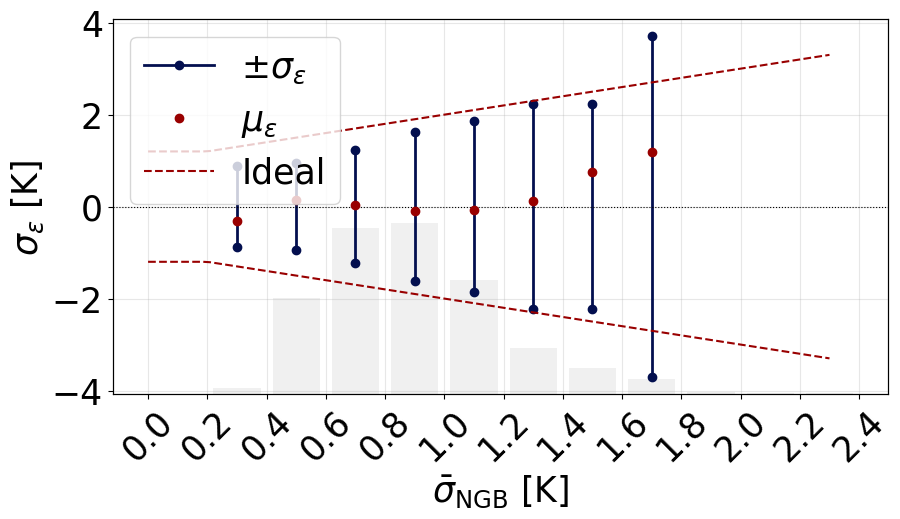

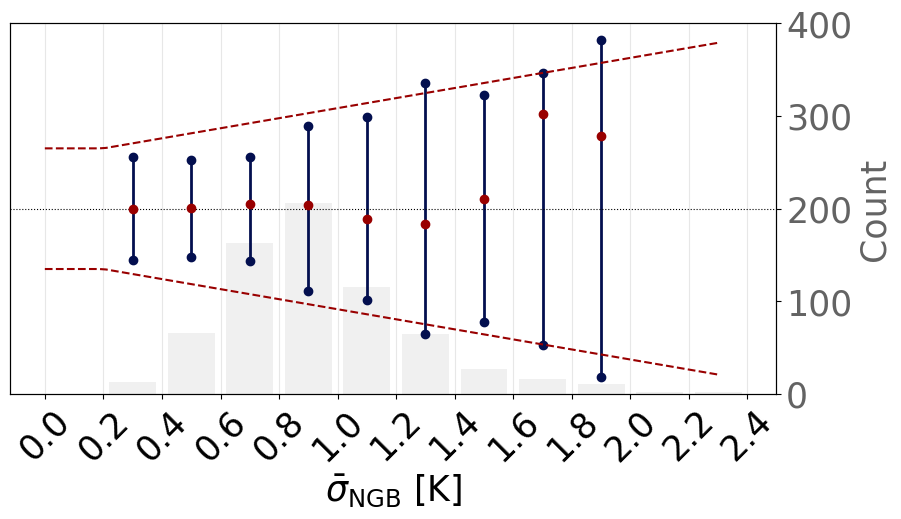

In [32]:
stats_ngb_ch45_2021 = compute_binned_stats_by_sigma(ngb_ch45_2021)
stats_ngb_ch4_2021  = compute_binned_stats_by_sigma(ngb_ch4_2021)

sigma_ch45_2021 = float(ngb_ch45_2021['residual'].std(ddof=1))
sigma_ch4_2021  = float(ngb_ch4_2021['residual'].std(ddof=1))

for stats, sigma, ylabel, show_legend, show_count_axis in [
    (stats_ngb_ch45_2021, sigma_ch45_2021, True,  True,  False),
    (stats_ngb_ch4_2021,  sigma_ch4_2021,  False, False, True),
]:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    plot_ngb_calibration(ax, stats, sigma, ylabel=ylabel,
                         show_legend=show_legend, show_count_axis=show_count_axis)
    plt.tight_layout()
    plt.show()

  [CH4+5 2021] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.
  [CH4  2021] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.
  [CH4+5 2025] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.
  [CH4  2025] fitting NGBRegressor... Using passed validation data to check for early stopping.
done.


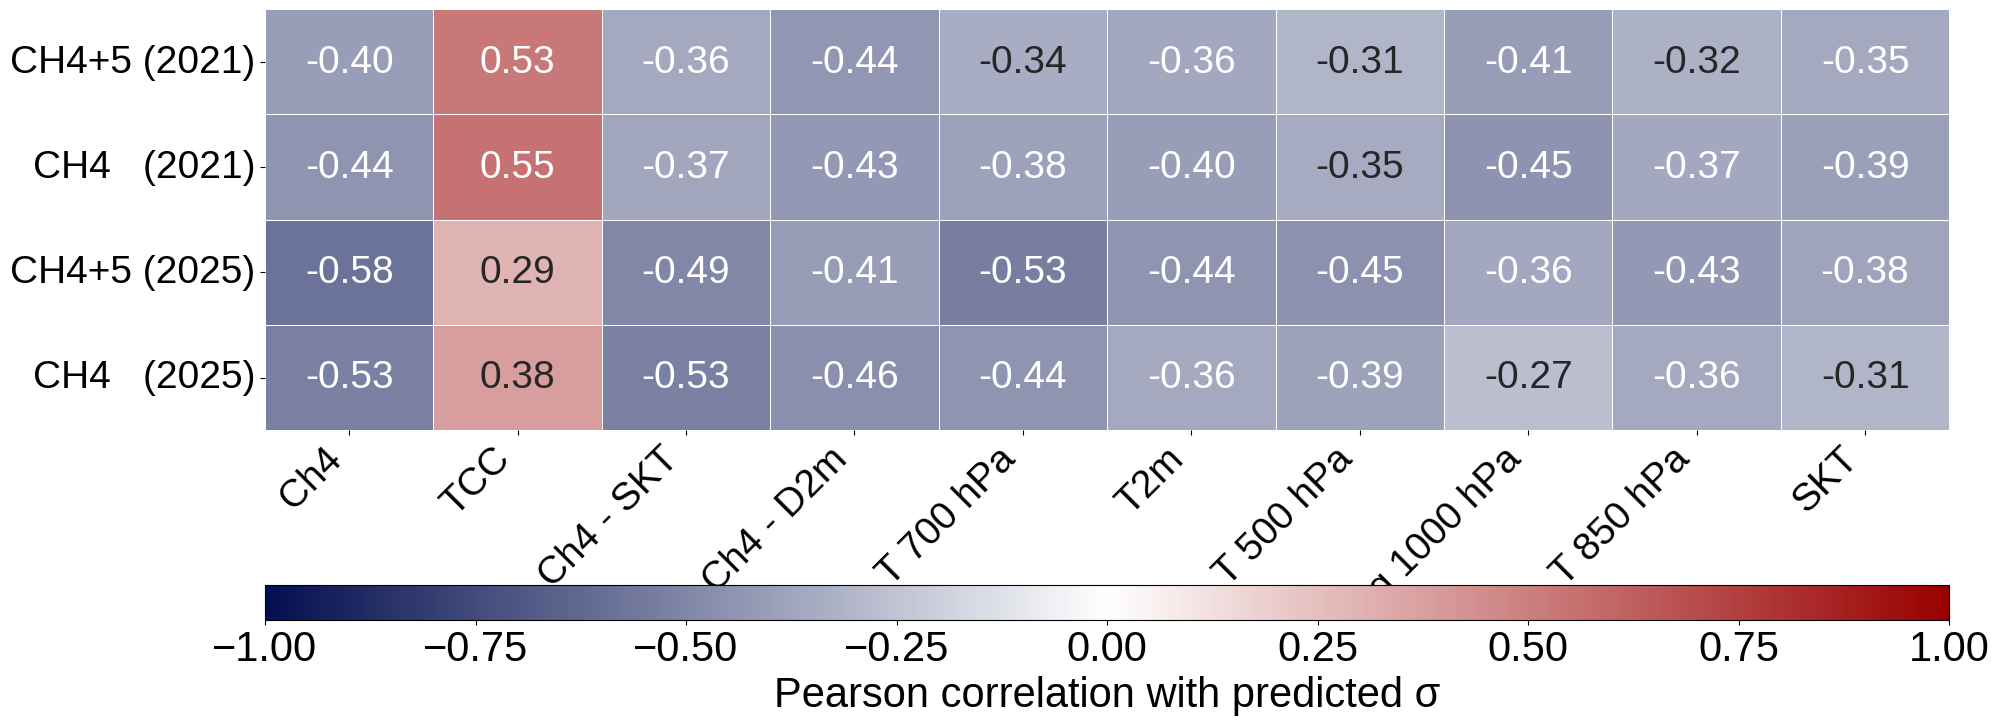

In [64]:
# ── Correlation between features and NGBoost predicted σ ────────────────
# Mirrors the bias-correlation heatmap, but with sigma on the y-axis.
# Tells you which features the model uses to *predict* uncertainty,
# which is distinct from which features correlate with actual error.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap

dtu_coolwarm_cmap = LinearSegmentedColormap.from_list(
    "dtu_coolwarm", [dtu_navy, '#ffffff', dtu_red])

textwidth_in = 6.38
plt.rcParams.update({
    "font.size": 30,
    "axes.labelsize": 30,
    "axes.titlesize": 30,
    "legend.fontsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
})

FEATURE_NAMES = {
    'lev1_sunzenith_angle':  'SZA',
    'lev1_satzenith_angle':  'VZA',
    'lev1_channel4':         'Ch4',
    'lev1_channel5':         'Ch5',
    'nwp_skt':               'SKT',
    'nwp_t2m':               'T2m',
    'nwp_d2m':               'D2m',
    'nwp_tcc':               'TCC',
    'nwp_tcw':               'TCW',
    'nwp_u10':               'U10',
    'nwp_v10':               'V10',
    'nwp_wind':              'Wind',
    'ch4_minus_skt':         'Ch4 - SKT',
    'ch4_minus_t2m':         'Ch4 - T2m',
    'ch4_minus_d2m':         'Ch4 - D2m',
    'ch5_minus_skt':         'Ch5 - SKT',
    'ch4_minus_ch5':         'Ch4 - Ch5',
    'sw_correction':         'SW corr',
    'sw_tcw':                'SW × TCW',
    'sw_sq':                 '(Ch4-Ch5)²',
    'dew_depression':        'Dew dep.',
}
FEATURE_NAMES.update({f'nwp_q_{p}_hPa': f'q {p} hPa'
                      for p in ['1000','850','700','500','300','200','100','50']})
FEATURE_NAMES.update({f'nwp_t_{p}_hPa': f'T {p} hPa'
                      for p in ['1000','850','700','500','300','200','100','50']})


def sigma_correlations(feats, train_df, test_df, label):
    """Refit NGBoost, predict σ on test_df, return Pearson corr of every
    feature in `feats` with the predicted σ."""
    tr = train_df[feats + [TARGET]].dropna()
    te = test_df [feats + [TARGET]].dropna()

    print(f'  [{label}] fitting NGBRegressor...', end=' ', flush=True)
    ngb = NGBRegressor(
        Dist=Normal,
        Base=_make_base(NGB_MAX_DEPTH),
        n_estimators=NGB_N_ESTIMATORS,
        learning_rate=NGB_LEARNING_RATE,
        random_state=NGB_SEED,
        verbose=False,
        early_stopping_rounds=NGB_EARLY_STOP,
    )
    # Early stopping picks M* automatically using the held-out set.
    ngb.fit(tr[feats].values.astype(float),
            tr[TARGET].values.astype(float),
            X_val=te[feats].values.astype(float),
            Y_val=te[TARGET].values.astype(float))
    print('done.')

    dist  = ngb.pred_dist(te[feats].values.astype(float))
    out   = te[feats].copy()
    out['sigma'] = dist.scale
    return out[feats + ['sigma']].corr()['sigma'].drop('sigma')


# ── Compute correlations for both years and both feature sets ───────────
corr_ch45_21 = sigma_correlations(SW_FEATS,     df_train_2021, df_test_2021, 'CH4+5 2021')
corr_ch4_21  = sigma_correlations(SW_FEATS_CH4, df_train_2021, df_test_2021, 'CH4  2021')
corr_ch45_25 = sigma_correlations(SW_FEATS,     df_train_2021, df_test_2025, 'CH4+5 2025')
corr_ch4_25  = sigma_correlations(SW_FEATS_CH4, df_train_2021, df_test_2025, 'CH4  2025')

# Restrict to the smaller (CH4-only) feature set so every row has the same columns
shared_feats = [f for f in SW_FEATS_CH4 if f in corr_ch45_21.index]
mean_abs = (corr_ch45_21.reindex(shared_feats).abs()
            + corr_ch4_21 .reindex(shared_feats).abs()
            + corr_ch45_25.reindex(shared_feats).abs()
            + corr_ch4_25 .reindex(shared_feats).abs()) / 4
top_feats = mean_abs.nlargest(10).index.tolist()

corr_df = pd.DataFrame({
    'CH4+5 (2021)': corr_ch45_21.reindex(top_feats),
    'CH4   (2021)': corr_ch4_21 .reindex(top_feats),
    'CH4+5 (2025)': corr_ch45_25.reindex(top_feats),
    'CH4   (2025)': corr_ch4_25 .reindex(top_feats),
}).T

# Rename columns to human-readable form
corr_df.columns = [FEATURE_NAMES.get(f, f.replace('_', ' ')) for f in corr_df.columns]

# ── Plot ────────────────────────────────────────────────────────────────
fig     = plt.figure(figsize=(textwidth_in * 3.0, textwidth_in * 1.1))
ax      = fig.add_axes([0.10, 0.32, 0.88, 0.60])
cbar_ax = fig.add_axes([0.10, 0.05, 0.88, 0.05])

sns.heatmap(
    corr_df,
    ax=ax,
    cmap=dtu_coolwarm_cmap,
    center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f',
    annot_kws={'size': 28},
    linewidths=0.4,
    cbar=False,
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=28, rotation=45, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), fontsize=28, rotation=0)

norm = mcolors.Normalize(vmin=-1, vmax=1)
sm   = cm.ScalarMappable(cmap=dtu_coolwarm_cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Pearson correlation with predicted σ', fontsize=30)
cbar.ax.tick_params(labelsize=30)

plt.show()

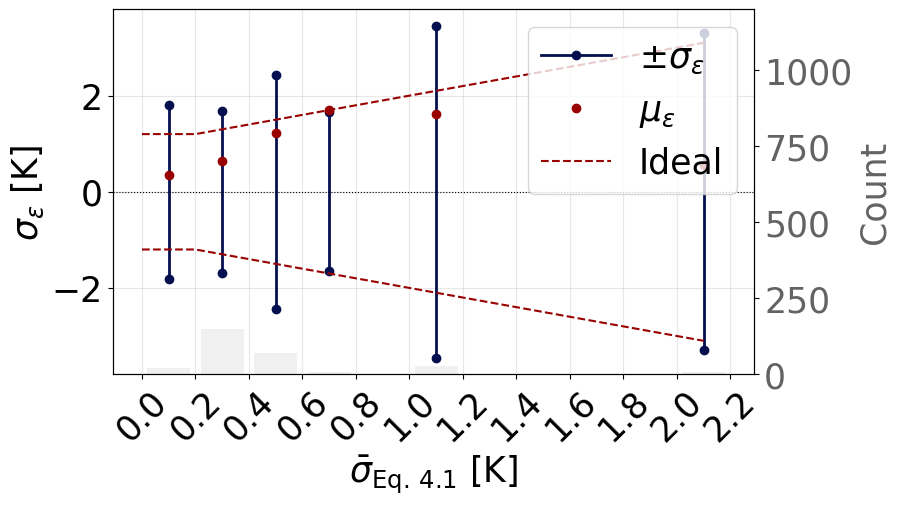

In [35]:
from matplotlib.lines import Line2D

# ── Classical retrieval uncertainty calibration (2025 holdout) ───────────
algo_cols = ['lev1_channel4', 'lev1_channel5', 'lev1_satzenith_angle',
             'total_uncertainty', TARGET]
te_algo = df_test_2025[algo_cols].dropna().copy()
T11   = te_algo['lev1_channel4'].values
T12   = te_algo['lev1_channel5'].values
sec_t = 1 / np.cos(np.radians(te_algo['lev1_satzenith_angle'].values))
yp_eq31 = (retrievals['algo2'][0]
           + retrievals['algo2'][1] * T11
           + retrievals['algo2'][2] * T12
           + retrievals['algo2'][3] * (T11 - T12) * (sec_t - 1))

eq31_df = pd.DataFrame({
    'residual': te_algo[TARGET].values - yp_eq31,
    'sigma'   : te_algo['total_uncertainty'].values,
})

stats_eq31 = compute_binned_stats_by_sigma(eq31_df)
sigma_eq31 = float(eq31_df['residual'].std(ddof=1))


def plot_classical_calibration(ax, stats, sigma, ylabel=True,
                                show_legend=True, show_count_axis=False):
    x    = np.array(stats['bin_mid'].values,      dtype=float)
    yerr = np.array(stats['std_residual'].values,  dtype=float)
    mean = np.array(stats['bin_mean'].values,      dtype=float)
    n    = stats['count'].values

    # ── Background histogram of counts ───────────────────────────────────
    ax_hist = ax.twinx()
    bin_width = x[1] - x[0] if len(x) > 1 else 0.5
    ax_hist.bar(x, n, width=bin_width * 0.8, color=dtu_grey, alpha=0.4,
                zorder=1, align='center')
    ax_hist.set_ylim(0, 1200) # Change this for changing count!
    ax_hist.yaxis.set_visible(show_count_axis)
    if show_count_axis:
        ax_hist.set_ylabel('Count', color=dtu_grey_dark)
        ax_hist.tick_params(axis='y', labelcolor=dtu_grey_dark)

    # ── ±σ_ε bars and μ_ε dots ───────────────────────────────────────────
    for xc, std, mn, ni in zip(x, yerr, mean, n):
        if np.isnan(std) or ni < 3:
            continue
        ax.plot([xc, xc], [-std, std], color=dtu_navy, lw=2, zorder=2)
        ax.plot(xc,  std, 'o', color=dtu_navy, ms=6, zorder=3)
        ax.plot(xc, -std, 'o', color=dtu_navy, ms=6, zorder=3)
        ax.plot(xc,  mn,  'o', color=dtu_red,  ms=6, zorder=4)

    x_line, y_plus, y_minus = optimal_lines(x.max(), sigma)
    ax.plot(x_line,  y_plus,  color=dtu_red, ls='--', lw=1.5, zorder=3)
    ax.plot(x_line,  y_minus, color=dtu_red, ls='--', lw=1.5, zorder=3)

    #ax.axhline(0, color='k', lw=0.8, ls=':', zorder=3)
    #ax.set_xlabel(r'$\bar{\sigma}_\mathrm{Eq.\,4.1}$ [K]')
    #ax.set_xticks(np.arange(0, x.max() + 0.5, 0.5))
    #ax.grid(alpha=0.3)
    #ax.set_zorder(ax_hist.get_zorder() + 1)
    #ax.patch.set_visible(False)
    ax.axhline(0, color='k', lw=0.8, ls=':', zorder=3)
    ax.set_xlabel(r'$\bar{\sigma}_\mathrm{Eq.\,4.1}$ [K]')
    ax.set_xticks(np.arange(0, x.max() + 0.2, 0.2))
    ax.tick_params('x', rotation=45)
    ax.grid(alpha=0.3)
    ax.set_zorder(ax_hist.get_zorder() + 1)
    ax.patch.set_visible(False)
    if ylabel:
        ax.set_ylabel(r'$\sigma_\varepsilon$ [K]')
    else:
        ax.yaxis.set_visible(False)

    if show_legend:
        legend_elements = [
            Line2D([0], [0], color=dtu_navy, lw=2, marker='o', ms=6,
                   label=r'$\pm\sigma_\varepsilon$'),
            Line2D([0], [0], color=dtu_red, lw=0, marker='o', ms=6,
                   label=r'$\mu_\varepsilon$'),
            Line2D([0], [0], color=dtu_red, lw=1.5, ls='--',
                   label=r'Ideal'),
        ]
        ax.legend(handles=legend_elements, loc='upper right')


fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
plot_classical_calibration(ax, stats_eq31, sigma_eq31,
                           ylabel=True, show_legend=True, show_count_axis=True)
plt.tight_layout()
plt.show()

df_v2: 3,430 rows | calib_orig: 3,430 | calib_new: 3,430


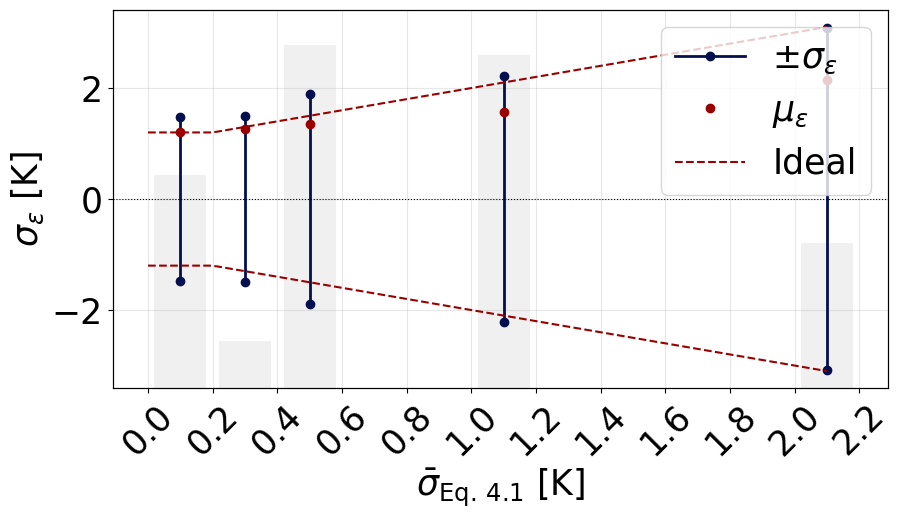

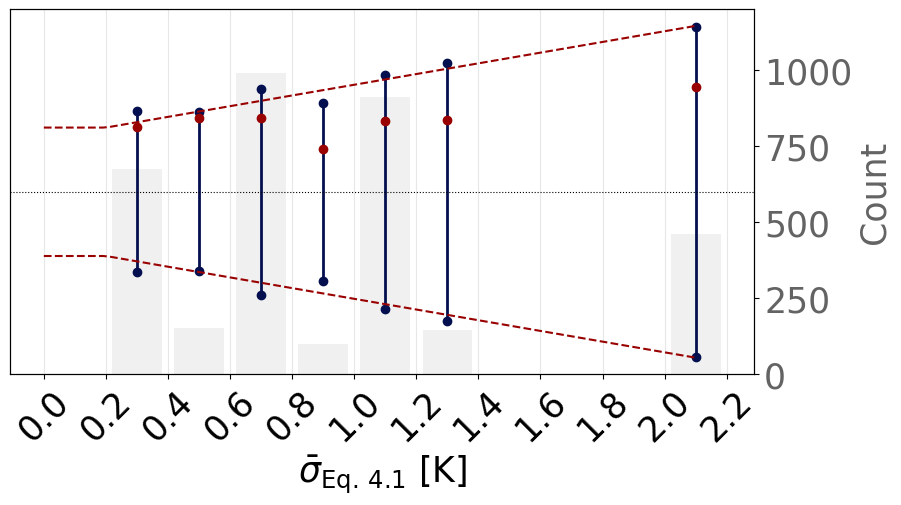

In [36]:
# ── Load v2 match-ups and build classical calibration frames ─────────────────
# Header row in this CSV is wrapped in quotes as a single field, so parse it manually.
with open('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv') as _f:
    _cols = [c.strip() for c in _f.readline().strip().strip('"').split(',')]
df_v2 = pd.read_csv('ALL_filter_mu_atmo_surf_obs2345_promistK_v2.csv',
                    skiprows=1, header=None, names=_cols)

# PROMICE truth is in °C, IST predictions are in K → convert truth to K.
_promice_K = df_v2['PROMICE_surface_temperature'] + 273.15

# residual = truth − prediction ; sigma = predicted total uncertainty
calib_orig = pd.DataFrame({
    'residual': _promice_K - df_v2['ist_orig'],
    'sigma'   : df_v2['unctot'],
}).dropna()

calib_new = pd.DataFrame({
    'residual': _promice_K - df_v2['ist_recalc'],
    'sigma'   : df_v2['unctot_new'],
}).dropna()

print(f'df_v2: {len(df_v2):,} rows | calib_orig: {len(calib_orig):,} | calib_new: {len(calib_new):,}')

for calib, ylabel, show_legend, show_count_axis in [
    (calib_orig, True,  True,  False),
    (calib_new,  False, False, True),
]:
    stats = compute_binned_stats_by_sigma(calib)
    sigma = float(calib['residual'].std(ddof=1))

    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    plot_classical_calibration(ax, stats, sigma, ylabel=ylabel,
                               show_legend=show_legend,
                               show_count_axis=show_count_axis)
    
    plt.tight_layout()
    plt.show()

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.


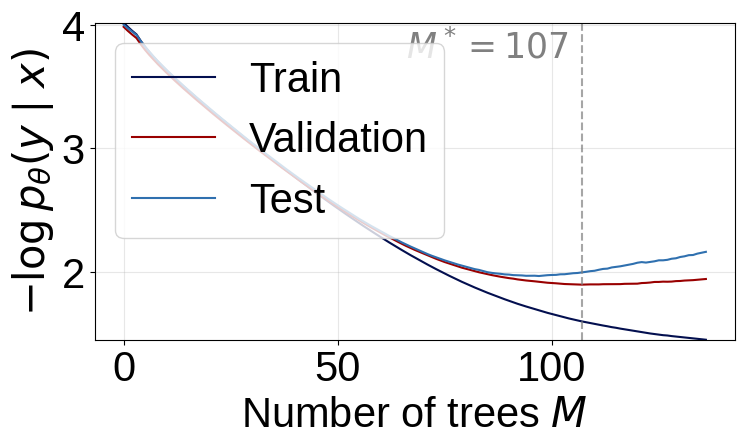

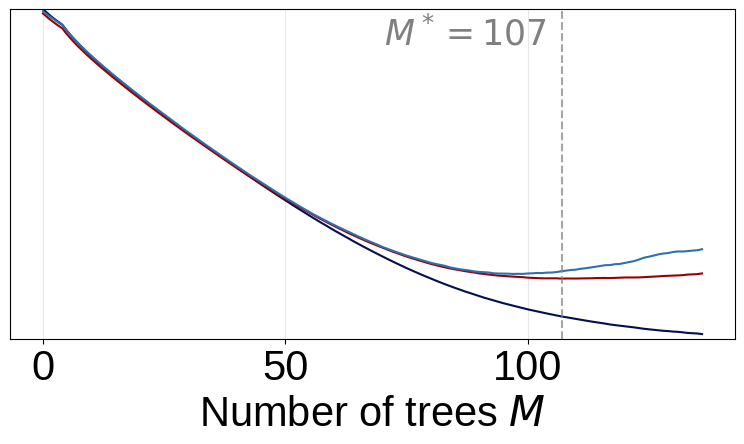

In [67]:
# ── NGBoost helpers ────────────────────────────────────────────────────────
from scipy.stats import norm

plt.rcParams.update({'font.size': 25})

def _fit_ngb(feats, seed, train_df, test_df, n_estimators, max_depth,
             learning_rate, early_stopping_rounds):
    """Shared setup and fitting logic for both NGBoost helpers."""
    tr  = train_df[feats + [TARGET]].dropna()
    te  = test_df[ feats + [TARGET]].dropna()
    Xtr = tr[feats].values.astype(float); ytr = tr[TARGET].values.astype(float)
    Xte = te[feats].values.astype(float); yte = te[TARGET].values.astype(float)
    ngb = NGBRegressor(
        Dist=Normal, Base=_make_base(max_depth),
        n_estimators=n_estimators, learning_rate=learning_rate,
        random_state=seed, verbose=False,
        early_stopping_rounds=early_stopping_rounds,
    )
    ngb.fit(Xtr, ytr, X_val=Xte, Y_val=yte)
    return ngb, Xtr, ytr, Xte, yte


def train_ngb_with_curve(feats, seed, train_df=None, test_df=None, holdout_df=None,
                          n_estimators=2000, max_depth=3, learning_rate=0.03,
                          early_stopping_rounds=200):
    if train_df is None: train_df = df_train_2021
    if test_df  is None: test_df  = df_test_2021
    ngb, Xtr, ytr, Xte, yte = _fit_ngb(
        feats, seed, train_df, test_df,
        n_estimators, max_depth, learning_rate, early_stopping_rounds,
    )
    best_round = ngb.best_val_loss_itr

    def _nll(y, dists):
        return [-np.mean(norm.logpdf(y, loc=d.loc, scale=d.scale)) for d in dists]

    train_nll = _nll(ytr, ngb.staged_pred_dist(Xtr))
    val_nll   = _nll(yte, ngb.staged_pred_dist(Xte))

    hold_nll = None
    if holdout_df is not None:
        ho  = holdout_df[feats + [TARGET]].dropna()
        Xho = ho[feats].values.astype(float)
        yho = ho[TARGET].values.astype(float)
        hold_nll = _nll(yho, ngb.staged_pred_dist(Xho))

    return train_nll, val_nll, hold_nll, best_round


def train_ngb(feats, seed, train_df=None, test_df=None,
              n_estimators=2000, max_depth=3, learning_rate=0.03,
              early_stopping_rounds=200):
    if train_df is None: train_df = df_train_2021
    if test_df  is None: test_df  = df_test_2021
    ngb, _, _, Xte, yte = _fit_ngb(
        feats, seed, train_df, test_df,
        n_estimators, max_depth, learning_rate, early_stopping_rounds,
    )
    yp = ngb.predict(Xte)
    return float(np.std(yte - yp, ddof=1)), yte, yp, ngb


# ── Plot ───────────────────────────────────────────────────────────────────
dtu_grey_dark = globals().get('dtu_grey_dark', '#636363')

_TAIL = 30
HOLDOUT = df_test_2025

# Pre-compute all curves to get global y limits
all_curves = []
for feats, label in [(SW_FEATS, "CH4+5"), (SW_FEATS_CH4, "CH4")]:
    tr_nll, val_nll, ho_nll, best = train_ngb_with_curve(
        feats, seed=SEED, holdout_df=HOLDOUT)
    all_curves.append((tr_nll, val_nll, ho_nll, best, label))

all_vals = []
for tr, val, ho, best, _ in all_curves:
    end = min(best + _TAIL, len(val))
    all_vals += tr[:end] + val[:end]
    if ho is not None:
        all_vals += ho[:end]
ylo_global = min(all_vals)
yhi_global = max(all_vals)

# Plot with shared limits
for i, (tr_nll, val_nll, ho_nll, best, label) in enumerate(all_curves):
    end = min(best + _TAIL, len(val_nll))
    xs  = range(end)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(xs, tr_nll[:end],  color=dtu_navy,      label="Train")
    ax.plot(xs, val_nll[:end], color=dtu_red,       label="Validation")
    if ho_nll is not None:
        ax.plot(xs, ho_nll[:end], color=dtu_blue, label="Test")
    ax.axvline(best, color="grey", linestyle="--", alpha=0.7)
    ax.set_ylim(ylo_global, yhi_global)
    ax.text(best - 3, yhi_global - 0.02 * (yhi_global - ylo_global),
            f"$M^* = {best}$", color="grey",
            fontsize=25, va="top", ha="right")
    ax.set_xlabel("Number of trees $M$")
    if i == 0:
        ax.set_ylabel(r"$-\log p_\theta(y \mid x)$")
        ax.legend(loc="upper left")
    else:
        ax.set_ylabel("")
        ax.set_yticks([])
        ax.tick_params(left=False)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Using passed validation data to check for early stopping.

CH4+5 | 2021
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP           390   +0.035    1.809    0.952 K
  KAN_U         157   -0.053    1.511    0.884 K
  KPC_U         121   +0.328    1.323    0.769 K
  UPE_U          18   -0.704    1.329    0.818 K
  ----------------------------------------------
  Overall       686   +0.047    1.661 K


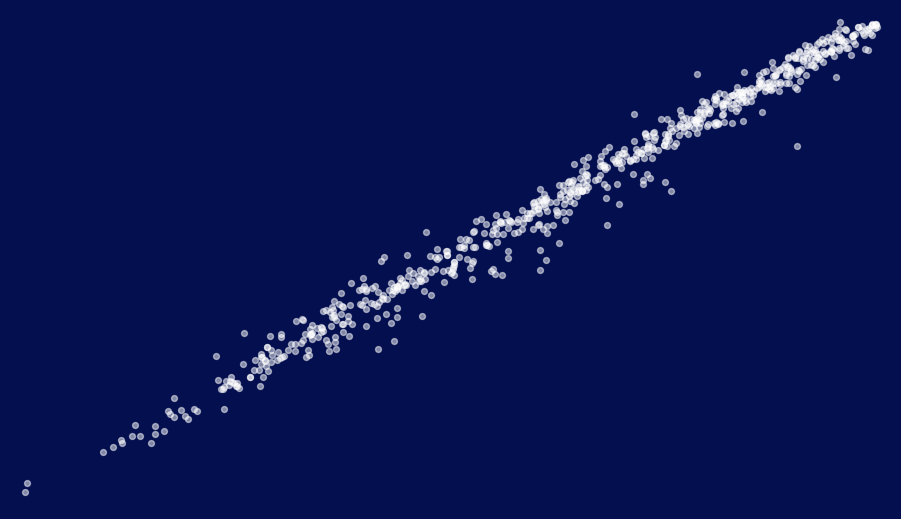

Using passed validation data to check for early stopping.

CH4+5 | 2025
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP            91   -0.532    1.670    0.947 K
  KAN_U          58   -0.420    1.883    0.699 K
  KPC_U         129   -0.686    1.389    0.842 K
  ----------------------------------------------
  Overall       278   -0.580    1.593 K


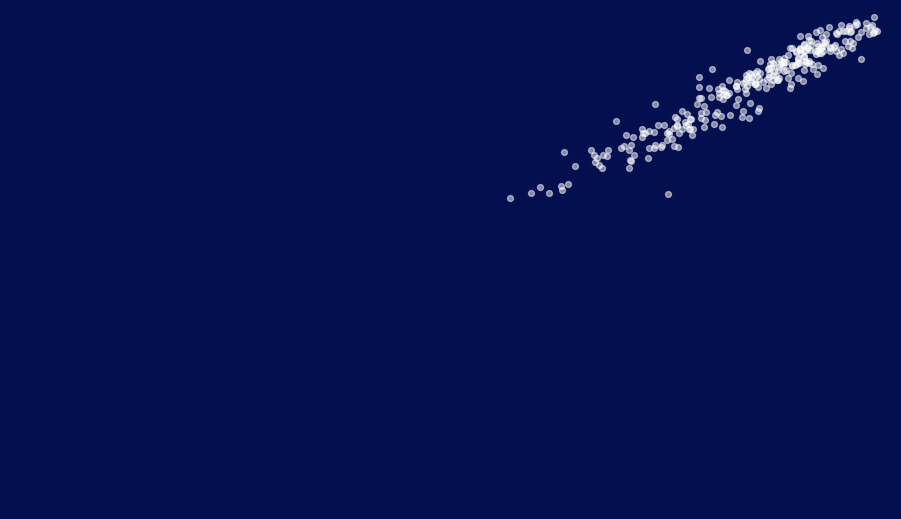

Using passed validation data to check for early stopping.

CH4 | 2021
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP           390   +0.081    1.879    1.009 K
  KAN_U         157   -0.074    1.575    0.920 K
  KPC_U         121   +0.278    1.332    0.783 K
  UPE_U          18   -0.720    1.471    0.852 K
  ----------------------------------------------
  Overall       686   +0.059    1.722 K


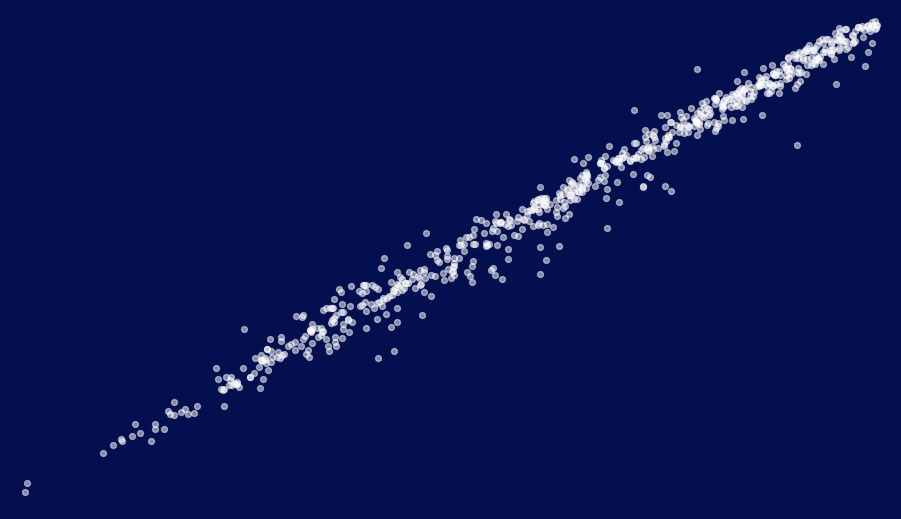

Using passed validation data to check for early stopping.

CH4 | 2025
  Station         N     Bias      σ_ε    σ_NGB
  ----------------------------------------------
  EGP            91   -0.410    1.629    0.948 K
  KAN_U          58   -0.233    1.855    0.756 K
  KPC_U         129   -0.588    1.486    0.886 K
  ----------------------------------------------
  Overall       278   -0.456    1.616 K


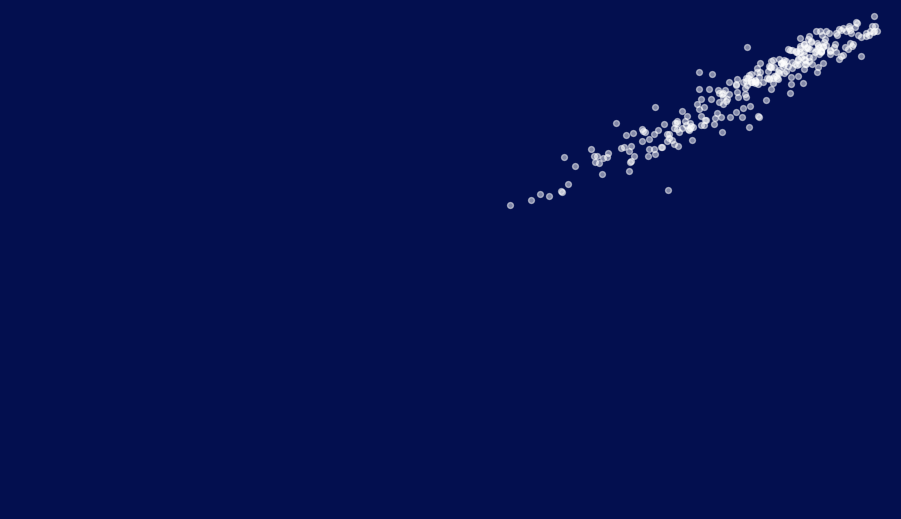

In [68]:
STATIONS_2021 = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']
STATIONS_2025 = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']

STATION_COLORS_ALL = {
    **STATION_COLORS,
    'SCO_U': '#2ca02c',
    'QAS_U': '#ff7f0e',
}

# ── Compute global axis limits across both years ──────────────────────────
all_y = []
for test_df in [df_test_2021, df_test_2025]:
    for feats in [SW_FEATS, SW_FEATS_CH4]:
        te = test_df[feats + [TARGET, 'station_id']].dropna().copy()
        all_y.append(te[TARGET].values)
all_y = np.concatenate(all_y)
global_lim = (all_y.min() - 1, all_y.max() + 1)

# ── Plot and statistics ───────────────────────────────────────────────────
for (feats, label), test_df, station_filter, show_yaxis, show_legend, set_label in [
    ((SW_FEATS,     'CH4+5'), df_test_2021, STATIONS_2021, True,  True,  '2021'),
    ((SW_FEATS,     'CH4+5'), df_test_2025, STATIONS_2025, False, False, '2025'),
    ((SW_FEATS_CH4, 'CH4'),   df_test_2021, STATIONS_2021, True,  False, '2021'),
    ((SW_FEATS_CH4, 'CH4'),   df_test_2025, STATIONS_2025, False, False, '2025'),
]:
    fig, ax = plt.subplots(figsize=(textwidth_in * 1.5, textwidth_in * 0.9))
    fig.patch.set_facecolor(dtu_navy)
    ax.set_facecolor(dtu_navy)

    _, _, _, gbm = train_ngb(feats, SEED, test_df=test_df)
    te = test_df[feats + [TARGET, 'station_id']].dropna().copy()
    te = te[te['station_id'].isin(station_filter)]
    te['y_pred'] = gbm.predict(te[feats].values.astype(float))

    print(f"\n{'='*60}")
    print(f"{label} | {set_label}")
    print(f"  {'Station':<10} {'N':>6} {'Bias':>8} {'σ_ε':>8} {'σ_NGB':>8}")
    print(f"  {'-'*46}")

    for st in station_filter:
        mask = te['station_id'] == st
        if mask.sum() == 0:
            continue

        y_te_st   = te.loc[mask, TARGET].values
        y_pred_st = te.loc[mask, 'y_pred'].values
        res_st    = y_te_st - y_pred_st
        bias      = res_st.mean()
        sigma     = res_st.std(ddof=1)

        dist_st      = gbm.pred_dist(te.loc[mask, feats].values.astype(float))
        sigma_ngb_st = float(dist_st.params['scale'].mean())

        print(f"  {st:<10} {mask.sum():>6} {bias:>+8.3f} {sigma:>8.3f} {sigma_ngb_st:>8.3f} K")

        ax.scatter(y_te_st, y_pred_st, alpha=0.50, s=18, color='white')

    res_all = te[TARGET].values - te['y_pred'].values
    print(f"  {'-'*46}")
    print(f"  {'Overall':<10} {len(te):>6} {res_all.mean():>+8.3f} "
          f"{res_all.std(ddof=1):>8.3f} K")

    ax.set_xlim(global_lim)
    ax.set_ylim(global_lim)

    # ── Strip everything: ticks, labels, frame, grid ─────────────────────
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()

In [69]:
# ── Leave-One-Station-Out cross-validation (NGBoost) ────────────────────────
# Holds out each station in turn: train on all OTHER stations, test on the
# held-out one. This probes spatial generalisation (how well the model does at
# a station it never saw in training) and complements the temporal 2025 holdout.
import numpy as np, inspect, logging
logging.getLogger("ngboost").setLevel(logging.ERROR)

# Reuse the notebook's tuned hyperparameters, passing only args train_ngb accepts.
_WANT = dict(max_depth=globals().get('NGB_MAX_DEPTH', 3),
             learning_rate=globals().get('NGB_LEARNING_RATE', 0.03),
             n_estimators=globals().get('NGB_N_ESTIMATORS', 2000),
             early_stopping_rounds=globals().get('NGB_EARLY_STOP', 200))
_HP = {k: v for k, v in _WANT.items()
       if k in set(inspect.signature(train_ngb).parameters)}

# Pool of labelled 2021 data (train + test split share the same stations/era).
_loso_pool = pd.concat([df_train_2021, df_test_2021], ignore_index=True)
LOSO_STATIONS = ['EGP', 'KAN_U', 'KPC_U', 'UPE_U']


def leave_one_station_out(feats, pool=_loso_pool, stations=LOSO_STATIONS, seed=SEED):
    """For each station: train on all others, evaluate on the held-out station.

    Early stopping needs a validation set; since the held-out station is the
    test fold, we carve a small in-distribution validation slice (10%) out of
    the training stations so M* is not chosen on the held-out data.
    Returns a per-station dict and the pooled (out-of-fold) std/bias.
    """
    rows, all_res = {}, []
    for st in stations:
        tr_full = pool[pool['station_id'] != st]
        te      = pool[pool['station_id'] == st]
        if len(te) == 0:
            rows[st] = None
            continue

        # in-distribution validation slice for early stopping (not the held-out station)
        val = tr_full.sample(frac=0.10, random_state=seed)
        tr  = tr_full.drop(val.index)

        std, y_te, y_pred, gbm = train_ngb(
            feats, seed, train_df=tr, test_df=te, **_HP
        )
        # mean predicted sigma from the distributional output, on the held-out station
        te_clean = te[feats + [TARGET]].dropna()
        sig = gbm.pred_dist(te_clean[feats].values.astype(float)).scale

        res = y_te - y_pred
        all_res.append(res)
        rows[st] = dict(N=len(y_te),
                        mu=float(res.mean()),
                        sd=float(std),
                        sng=float(np.mean(sig)))

    pooled = np.concatenate(all_res) if all_res else np.array([])
    overall = dict(N=int(pooled.size),
                   mu=float(pooled.mean()) if pooled.size else float('nan'),
                   sd=float(pooled.std(ddof=1)) if pooled.size else float('nan'))
    return rows, overall


def _print_loso(name, rows, overall):
    print(f"\n{'='*72}\n  {name}  Leave-One-Station-Out CV (2021)\n{'='*72}")
    print(f"  {'Held-out':<8} {'N':>5} {'bias[K]':>9} {'std[K]':>8} {'sig_NGB[K]':>11}")
    print(f"  {'-'*8} {'-'*5} {'-'*9} {'-'*8} {'-'*11}")
    for st in LOSO_STATIONS:
        s = rows.get(st)
        if s is None:
            print(f"  {st:<8} {'--':>5} {'--':>9} {'--':>8} {'--':>11}")
        else:
            print(f"  {st:<8} {s['N']:>5} {s['mu']:>+9.3f} {s['sd']:>8.3f} {s['sng']:>11.3f}")
    print(f"  {'-'*8} {'-'*5} {'-'*9} {'-'*8} {'-'*11}")
    print(f"  {'Pooled':<8} {overall['N']:>5} {overall['mu']:>+9.3f} {overall['sd']:>8.3f}")


# Run for both feature sets
loso_ch45, overall_ch45 = leave_one_station_out(SW_FEATS)
loso_ch4,  overall_ch4  = leave_one_station_out(SW_FEATS_CH4)

_print_loso("Two-channel (Ch4+Ch5)", loso_ch45, overall_ch45)
_print_loso("One-channel (Ch4)",     loso_ch4,  overall_ch4)

# ── LaTeX block (same layout as tab:station_stats) ──────────────────────────
def _loso_row(label, key, rows_tc, rows_oc, fmt):
    def cells(rows):
        return ' & '.join('--' if rows[st] is None else fmt(rows[st][key])
                          for st in LOSO_STATIONS)
    return f"& {label} & {cells(rows_tc)} & {cells(rows_oc)} \\\\"

print(f"\n{'='*72}\n  LaTeX (leave-one-station-out, 2021)\n{'='*72}")
print(_loso_row("$N$",                          'N',   loso_ch45, loso_ch4, lambda v: f'{v}'))
print(_loso_row(r"$\mu_\varepsilon$ [K]",       'mu',  loso_ch45, loso_ch4, lambda v: f'${v:+.3f}$'))
print(_loso_row(r"$\sigma_\varepsilon$ [K]",    'sd',  loso_ch45, loso_ch4, lambda v: f'${v:.3f}$'))
print(_loso_row(r"$\bar{\sigma}_\text{NGB}$ [K]",'sng', loso_ch45, loso_ch4, lambda v: f'${v:.3f}$'))

Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.
Using passed validation data to check for early stopping.

  Two-channel (Ch4+Ch5)  Leave-One-Station-Out CV (2021)
  Held-out     N   bias[K]   std[K]  sig_NGB[K]
  -------- ----- --------- -------- -----------
  EGP       1336    -1.434    2.742       0.666
  KAN_U      534    +0.050    1.885       0.935
  KPC_U      362    +0.739    1.244       0.837
  UPE_U       62    -0.585    1.799       0.895
  -------- ----- --------- -------- -----------
  Pooled    2294    -0.723    2.511

  One-channel (Ch4)  Leave-One-Station-Out CV (2021)
  Held-out     N   bias[K]   std[K]  sig_NGB[K]
  --

In [70]:
# ── Leave-One-Month-Out cross-validation (NGBoost) ──────────────────────────
# Holds out each calendar month in turn: train on all OTHER months, test on the
# held-out one. Probes temporal generalisation within 2021 (how well the model
# does on a month it never saw), complementing the spatial LOSO and the 2025 holdout.
import numpy as np, inspect, logging, calendar as _cal
logging.getLogger("ngboost").setLevel(logging.ERROR)

_WANT = dict(max_depth=globals().get('NGB_MAX_DEPTH', 3),
             learning_rate=globals().get('NGB_LEARNING_RATE', 0.03),
             n_estimators=globals().get('NGB_N_ESTIMATORS', 2000),
             early_stopping_rounds=globals().get('NGB_EARLY_STOP', 200))
_HP = {k: v for k, v in _WANT.items()
       if k in set(inspect.signature(train_ngb).parameters)}

# Pool of labelled 2021 data; ensure a 'month' column exists.
_lomo_pool = pd.concat([df_train_2021, df_test_2021], ignore_index=True)
if 'month' not in _lomo_pool.columns:
    _lomo_pool['month'] = pd.to_datetime(_lomo_pool['lev1_obstime']).dt.month

# Only months actually present in the pool, in calendar order.
LOMO_MONTHS = sorted(int(m) for m in _lomo_pool['month'].dropna().unique())


def leave_one_month_out(feats, pool=_lomo_pool, months=LOMO_MONTHS, seed=SEED):
    """For each month: train on all others, evaluate on the held-out month.

    Early stopping needs a validation set; since the held-out month is the test
    fold, we carve a small in-distribution validation slice (10%) out of the
    training months so M* is not chosen on the held-out data.
    Returns a per-month dict and the pooled (out-of-fold) std/bias.
    """
    rows, all_res = {}, []
    for m in months:
        tr_full = pool[pool['month'] != m]
        te      = pool[pool['month'] == m]
        if len(te) == 0:
            rows[m] = None
            continue

        val = tr_full.sample(frac=0.10, random_state=seed)
        tr  = tr_full.drop(val.index)

        std, y_te, y_pred, gbm = train_ngb(
            feats, seed, train_df=tr, test_df=te, **_HP
        )
        te_clean = te[feats + [TARGET]].dropna()
        sig = gbm.pred_dist(te_clean[feats].values.astype(float)).scale

        res = y_te - y_pred
        all_res.append(res)
        rows[m] = dict(N=len(y_te),
                       mu=float(res.mean()),
                       sd=float(std),
                       sng=float(np.mean(sig)))

    pooled = np.concatenate(all_res) if all_res else np.array([])
    overall = dict(N=int(pooled.size),
                   mu=float(pooled.mean()) if pooled.size else float('nan'),
                   sd=float(pooled.std(ddof=1)) if pooled.size else float('nan'))
    return rows, overall


def _print_lomo(name, rows, overall):
    print(f"\n{'='*72}\n  {name}  Leave-One-Month-Out CV (2021)\n{'='*72}")
    print(f"  {'Held-out':<8} {'N':>5} {'bias[K]':>9} {'std[K]':>8} {'sig_NGB[K]':>11}")
    print(f"  {'-'*8} {'-'*5} {'-'*9} {'-'*8} {'-'*11}")
    for m in LOMO_MONTHS:
        s = rows.get(m)
        lbl = _cal.month_abbr[m]
        if s is None:
            print(f"  {lbl:<8} {'--':>5} {'--':>9} {'--':>8} {'--':>11}")
        else:
            print(f"  {lbl:<8} {s['N']:>5} {s['mu']:>+9.3f} {s['sd']:>8.3f} {s['sng']:>11.3f}")
    print(f"  {'-'*8} {'-'*5} {'-'*9} {'-'*8} {'-'*11}")
    print(f"  {'Pooled':<8} {overall['N']:>5} {overall['mu']:>+9.3f} {overall['sd']:>8.3f}")


# Run for both feature sets
lomo_ch45, overall_m_ch45 = leave_one_month_out(SW_FEATS)
lomo_ch4,  overall_m_ch4  = leave_one_month_out(SW_FEATS_CH4)

_print_lomo("Two-channel (Ch4+Ch5)", lomo_ch45, overall_m_ch45)
_print_lomo("One-channel (Ch4)",     lomo_ch4,  overall_m_ch4)

# ── LaTeX block (months as columns) ─────────────────────────────────────────
def _lomo_row(label, key, rows_tc, rows_oc, fmt):
    def cells(rows):
        return ' & '.join('--' if rows[m] is None else fmt(rows[m][key])
                          for m in LOMO_MONTHS)
    return f"& {label} & {cells(rows_tc)} & {cells(rows_oc)} \\\\"

print(f"\n{'='*72}\n  LaTeX (leave-one-month-out, 2021)\n{'='*72}")
print("  months:", ' & '.join(_cal.month_abbr[m] for m in LOMO_MONTHS))
print(_lomo_row("$N$",                           'N',   lomo_ch45, lomo_ch4, lambda v: f'{v}'))
print(_lomo_row(r"$\mu_\varepsilon$ [K]",        'mu',  lomo_ch45, lomo_ch4, lambda v: f'${v:+.3f}$'))
print(_lomo_row(r"$\sigma_\varepsilon$ [K]",     'sd',  lomo_ch45, lomo_ch4, lambda v: f'${v:.3f}$'))
print(_lomo_row(r"$\bar{\sigma}_\text{NGB}$ [K]", 'sng', lomo_ch45, lomo_ch4, lambda v: f'${v:.3f}$'))

Using passed validation data to check for early stopping.


KeyboardInterrupt: 

Using passed validation data to check for early stopping.


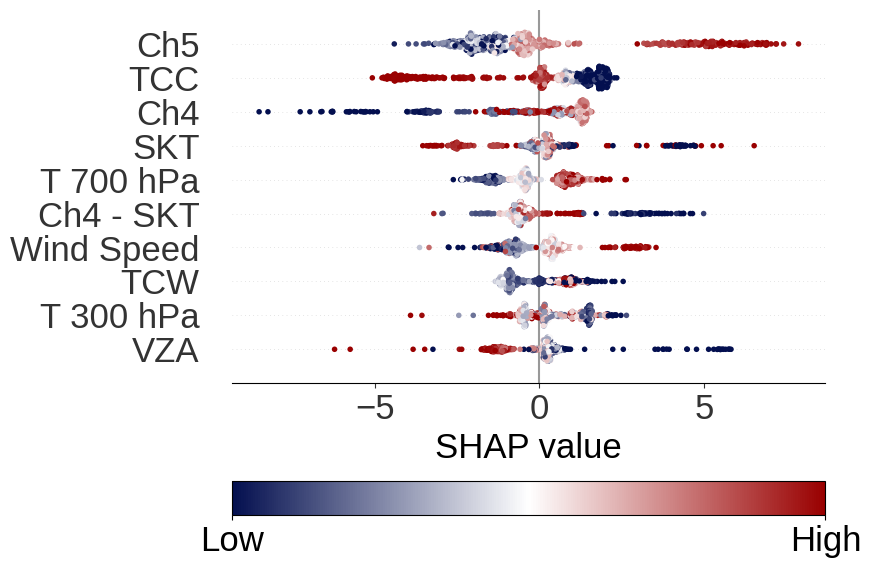

Using passed validation data to check for early stopping.


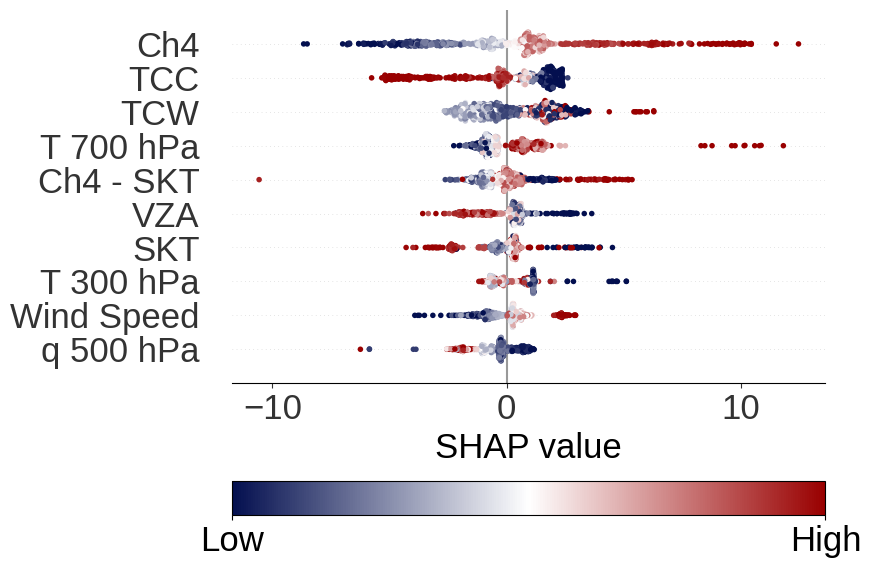

In [ ]:
import shap
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import matplotlib

# ── DTU color scheme ──────────────────────────────────────────────────────
matplotlib.rcParams['font.family'] = 'Liberation Sans'

dtu_navy = '#030F4F'
dtu_red  = '#990000'
white    = '#ffffff'

dtu_coolwarm_cmap = LinearSegmentedColormap.from_list(
    "dtu_coolwarm", [dtu_navy, white, dtu_red])

# ── Layout ────────────────────────────────────────────────────────────────
textwidth_in = 6.38
fs           = 25

plt.rcParams.update({
    "font.size":       fs,
    "axes.labelsize":  fs,
    "axes.titlesize":  fs,
    "legend.fontsize": fs,
    "xtick.labelsize": fs,
    "ytick.labelsize": fs,
})

FEATURE_NAMES = {
    'lev1_sunzenith_angle':  'SZA',
    'lev1_satzenith_angle':  'VZA',
    'lev1_channel4':         'Ch4',
    'lev1_channel5':         'Ch5',
    'nwp_skt':               'SKT',
    'nwp_t2m':               'T2m',
    'nwp_d2m':               'D2m',
    'nwp_tcc':               'TCC',
    'nwp_tcw':               'TCW',
    'nwp_u10':               'U10',
    'nwp_v10':               'V10',
    'nwp_wind':              'Wind Speed',
    'ch4_minus_skt':         'Ch4 - SKT',
    'ch4_minus_t2m':         'Ch4 - T2m',
    'ch4_minus_d2m':         'Ch4 - D2m',
    'dew_depression':        'Dew Dep.',
    'nwp_q_1000_hPa':        'q 1000 hPa',
    'nwp_q_850_hPa':         'q 850 hPa',
    'nwp_q_700_hPa':         'q 700 hPa',
    'nwp_q_500_hPa':         'q 500 hPa',
    'nwp_q_300_hPa':         'q 300 hPa',
    'nwp_q_200_hPa':         'q 200 hPa',
    'nwp_q_100_hPa':         'q 100 hPa',
    'nwp_q_50_hPa':          'q 50 hPa',
    'nwp_t_1000_hPa':        'T 1000 hPa',
    'nwp_t_850_hPa':         'T 850 hPa',
    'nwp_t_700_hPa':         'T 700 hPa',
    'nwp_t_500_hPa':         'T 500 hPa',
    'nwp_t_300_hPa':         'T 300 hPa',
    'nwp_t_200_hPa':         'T 200 hPa',
    'nwp_t_100_hPa':         'T 100 hPa',
    'nwp_t_50_hPa':          'T 50 hPa',
}

# ── SHAP for NGBoost predicted uncertainty: aggregate over SCALE base trees ─
# NGBoost stores base_models as a list of (loc_tree, scale_tree) pairs.
# We sum SHAP values across all SCALE trees -> attribution to predicted log-sigma.
for feats, ch in [(SW_FEATS, 'CH4+5'), (SW_FEATS_CH4, 'CH4')]:

    te  = df_test_2021[feats + [TARGET]].dropna().copy()
    Xte = te[feats].values.astype(float)
    _, _, _, ngb = train_ngb(feats, SEED, test_df=df_test_2021)

    # Sum SHAP values across all scale base models
    shap_values = np.zeros_like(Xte)
    for _, scale_tree in ngb.base_models:
        explainer    = shap.TreeExplainer(scale_tree)
        shap_values += explainer.shap_values(Xte)

    # Top 10 by mean absolute SHAP
    mean_abs    = np.abs(shap_values).mean(axis=0)
    top10_idx   = np.argsort(mean_abs)[-10:]
    top10_feats = [feats[i] for i in top10_idx]
    top10_shap  = shap_values[:, top10_idx]
    top10_X     = Xte[:, top10_idx]

    top10_feats_display = [FEATURE_NAMES.get(f, f.replace('_', ' '))
                           for f in top10_feats]

    # ── Render ────────────────────────────────────────────────────────────
    shap.summary_plot(
        top10_shap,
        top10_X,
        feature_names=top10_feats_display,
        plot_type='dot',
        show=False,
        plot_size=(textwidth_in * 1.5, textwidth_in * 0.9),
        max_display=10,
    )

    fig = plt.gcf()
    main_ax = fig.axes[0]
    main_ax.set_xlabel(r'SHAP value', fontsize=fs)
    main_ax.tick_params(axis='x', labelsize=fs)
    main_ax.tick_params(axis='y', labelsize=fs)

    # ── Recolour collections and grab mappable ────────────────────────────
    mappable = None
    for coll in main_ax.collections:
        arr = coll.get_array()
        if arr is not None and len(arr) > 0:
            coll.set_cmap(dtu_coolwarm_cmap)
            if mappable is None:
                mappable = coll
    for im in main_ax.get_images():
        im.set_cmap(dtu_coolwarm_cmap)

    # ── Remove existing vertical colorbar axes ────────────────────────────
    for ax_ in fig.axes[1:]:
        ax_.remove()

    main_ax.set_position([0.35, 0.28, 0.62, 0.65])

    cbar_ax = fig.add_axes([0.35, 0.05, 0.62, 0.06])

    norm = mcolors.Normalize(vmin=mappable.norm.vmin, vmax=mappable.norm.vmax)
    sm   = cm.ScalarMappable(cmap=dtu_coolwarm_cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_ticks([norm.vmin, norm.vmax])
    cbar.set_ticklabels(['Low', 'High'], fontsize=fs)
    cbar.ax.tick_params(labelsize=fs)

    plt.show()